In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.stats import mannwhitneyu

In [4]:
# Load immune cell fractions (assuming tab-separated format)
xcell = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/TCGA/xcell_TCGA/LUAD_xcell.tsv", sep="\t", index_col=0)

# Load CNV data from LUAD folder
cnv_data = pd.read_csv("LUAD_cnv_table_purity_rescale.txt", sep="\t", index_col=0)

# Standardize CNV column names
cnv_data.columns = cnv_data.columns.str.replace("^X", "", regex=True)


# === Clean sample IDs to first 12 characters ===
xcell.index = xcell.index.str.slice(0, 12)
cnv_data.index = cnv_data.index.str.slice(0, 12)

In [5]:
# === Compute M1 / (M1 + M2) ===
xcell_m1_m2 = xcell[["Macrophage M1", "Macrophage M2"]].copy()
xcell_m1_m2["M1_frac"] = xcell_m1_m2["Macrophage M1"] / (
    xcell_m1_m2["Macrophage M1"] + xcell_m1_m2["Macrophage M2"] + 1e-6
)

# === Merge with CNV ===
merged = xcell_m1_m2.merge(cnv_data, left_index=True, right_index=True)

# Log-transform to suppress extreme outliers
# merged["log_M1_M2_ratio"] = np.log2(merged["M1_M2_ratio"] + 1e-6)
print(merged.columns.tolist())

['Macrophage M1', 'Macrophage M2', 'M1_frac', 'Chrom1', 'Chrom2', 'Chrom3', 'Chrom4', 'Chrom5', 'Chrom6', 'Chrom7', 'Chrom8', 'Chrom9', 'Chrom10', 'Chrom11', 'Chrom12', 'Chrom13', 'Chrom14', 'Chrom15', 'Chrom16', 'Chrom17', 'Chrom18', 'Chrom19', 'Chrom20', 'Chrom21', 'Chrom22', 'ChromX', 'Arm1p', 'Arm1q', 'Arm2p', 'Arm2q', 'Arm3p', 'Arm3q', 'Arm4p', 'Arm4q', 'Arm5p', 'Arm5q', 'Arm6p', 'Arm6q', 'Arm7p', 'Arm7q', 'Arm8p', 'Arm8q', 'Arm9p', 'Arm9q', 'Arm10p', 'Arm10q', 'Arm11p', 'Arm11q', 'Arm12p', 'Arm12q', 'Arm13q', 'Arm14q', 'Arm15q', 'Arm16p', 'Arm16q', 'Arm17p', 'Arm17q', 'Arm18p', 'Arm18q', 'Arm19p', 'Arm19q', 'Arm20p', 'Arm20q', 'Arm21q', 'Arm22q', 'ArmXp', 'ArmXq', '10p11.1', '10p11.21', '10p11.22', '10p11.23', '10p12.1', '10p12.2', '10p12.31', '10p12.33', '10p13', '10p14', '10p15.1', '10p15.2', '10p15.3', '10q11.21', '10q11.22', '10q11.23', '10q21.1', '10q21.2', '10q21.3', '10q22.1', '10q22.2', '10q22.3', '10q23.1', '10q23.2', '10q23.31', '10q23.32', '10q23.33', '10q24.1', '10q24

/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_27101/428760145.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


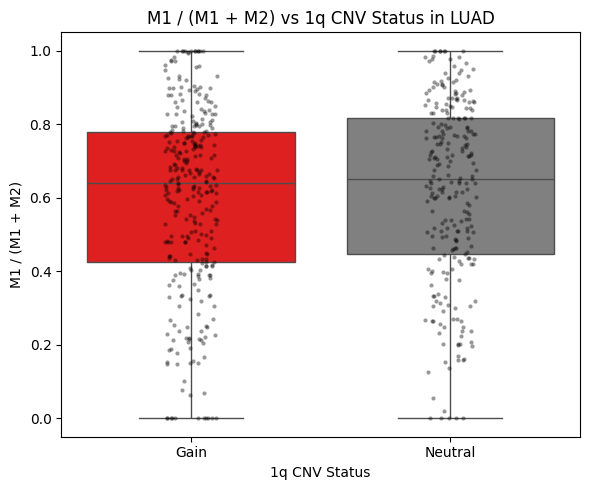

Wilcoxon p-value (Gain vs Neutral): 0.2652


In [7]:
# === Define CNV status for 1q ===
merged["Arm_1q_status"] = merged["Arm1q"].apply(
    lambda x: "Gain" if x > 0.2 else "Neutral" if x > -0.2 else "Loss"
)

# === Filter to Gain vs Neutral (optional) ===
filtered = merged[merged["Arm_1q_status"].isin(["Gain", "Neutral"])]

# === Plot boxplot ===
plt.figure(figsize=(6, 5))
sns.boxplot(
    data=filtered,
    x="Arm_1q_status",
    y="M1_frac",
    palette={"Gain": "red", "Neutral": "gray"}
)
sns.stripplot(
    data=filtered,
    x="Arm_1q_status",
    y="M1_frac",
    color="black",
    size=3,
    jitter=True,
    alpha=0.4
)
plt.title("M1 / (M1 + M2) vs 1q CNV Status in LUAD")
plt.ylabel("M1 / (M1 + M2)")
plt.xlabel("1q CNV Status")
plt.tight_layout()
# plt.savefig("LUAD_1q_M1_fraction_boxplot.pdf")
# plt.close()
plt.show()
# === Wilcoxon test (Gain vs Neutral) ===
gain_vals = filtered[filtered["Arm_1q_status"] == "Gain"]["M1_frac"]
neutral_vals = filtered[filtered["Arm_1q_status"] == "Neutral"]["M1_frac"]

stat, p = mannwhitneyu(gain_vals, neutral_vals, alternative="two-sided")
print(f"Wilcoxon p-value (Gain vs Neutral): {p:.4g}")

In [16]:
print(cnv_data.index[:5])
print(xcell_m1_m2.index[:5])
print(merged.shape)
print(merged[["Arm1q", "M1_M2_ratio"]].head())

Index(['TCGA-05-4244', 'TCGA-05-4249', 'TCGA-05-4250', 'TCGA-05-4382',
       'TCGA-05-4384'],
      dtype='object')
Index(['TCGA-55-6972', 'TCGA-05-4410', 'TCGA-91-6847', 'TCGA-91-6848',
       'TCGA-73-7499'],
      dtype='object')
(595, 873)
                 Arm1q   M1_M2_ratio
TCGA-55-6972  0.521846  7.454840e-18
TCGA-05-4410  0.654951  2.738051e+00
TCGA-91-6847  0.616340  0.000000e+00
TCGA-91-6848  0.000000  5.358349e+01
TCGA-73-7499  0.000000  1.666388e+00


In [21]:
print(merged["Arm_1q_status"].value_counts(dropna=False))

Arm_1q_status
Gain       312
Neutral    257
Loss        26
Name: count, dtype: int64


In [22]:
import numpy as np
print(filtered["M1_M2_ratio"].describe())
print(filtered["M1_M2_ratio"].sort_values(ascending=False).head(10))
print((filtered["M1_M2_ratio"] > 100).sum())

count      569.000000
mean       797.777973
std       5602.657984
min          0.000000
25%          0.769208
50%          1.818082
75%          3.885240
max      63555.266040
Name: M1_M2_ratio, dtype: float64
TCGA-55-6985    63555.266040
TCGA-MP-A4SV    59070.978106
TCGA-44-8119    54211.354889
TCGA-NJ-A4YP    41082.823729
TCGA-44-5645    41053.558849
TCGA-MP-A4T8    36377.691011
TCGA-93-A4JQ    33776.306942
TCGA-55-A48X    26367.041116
TCGA-78-7166    20438.884271
TCGA-49-AAR9    14764.827689
Name: M1_M2_ratio, dtype: float64
20


Wilcoxon p-value (Gain vs Neutral): 0.2652


/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_28785/963236990.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


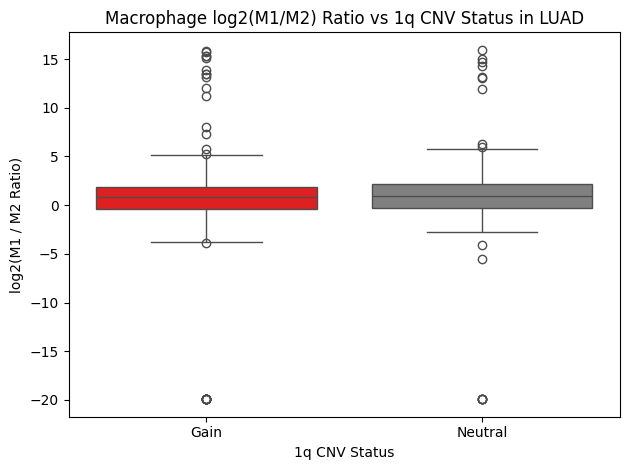

In [26]:
# Classify 1q status
merged["Arm_1q_status"] = merged["Arm1q"].apply(lambda x: "Gain" if x > 0.2 else "Neutral" if x > -0.2 else "Loss")

# (Optional) Filter to Gain vs Neutral
filtered = merged[merged["Arm_1q_status"].isin(["Gain", "Neutral"])]

# Boxplot using log-transformed values
sns.boxplot(
    data=filtered,
    x="Arm_1q_status",
    y="log_M1_M2_ratio",
    palette={"Gain": "red", "Neutral": "grey"}
)

plt.title("Macrophage log2(M1/M2) Ratio vs 1q CNV Status in LUAD")
plt.ylabel("log2(M1 / M2 Ratio)")
plt.xlabel("1q CNV Status")
plt.tight_layout()
# plt.savefig("LUAD_1q_logM1M2_ratio_boxplot.pdf")

# Wilcoxon test on log values
gain = filtered[filtered["Arm_1q_status"] == "Gain"]["log_M1_M2_ratio"]
neutral = filtered[filtered["Arm_1q_status"] == "Neutral"]["log_M1_M2_ratio"]
stat, p = mannwhitneyu(gain, neutral, alternative="two-sided")

print(f"Wilcoxon p-value (Gain vs Neutral): {p:.4g}")

In [21]:
# Load immune cell fractions (assuming tab-separated format)
xcell_data = pd.read_csv("LUAD_xcell.tsv", sep="\t", index_col=0)

selected_cells = [
    "CD8_T_cells", "T cell CD4+ memory", "T cell CD4+ (non-regulatory)", "Endothelium", "Fibroblasts",
    "Mast cell", "Monocytes", "Dendritic_cells", "Macrophage M1", "Macrophage M2", "B_cells", "NK_cells"
]

# Subset only the relevant immune cells
xcell_data  = xcell_data[selected_cells]
xcell_data.index = xcell_data.index.str[:-3] 


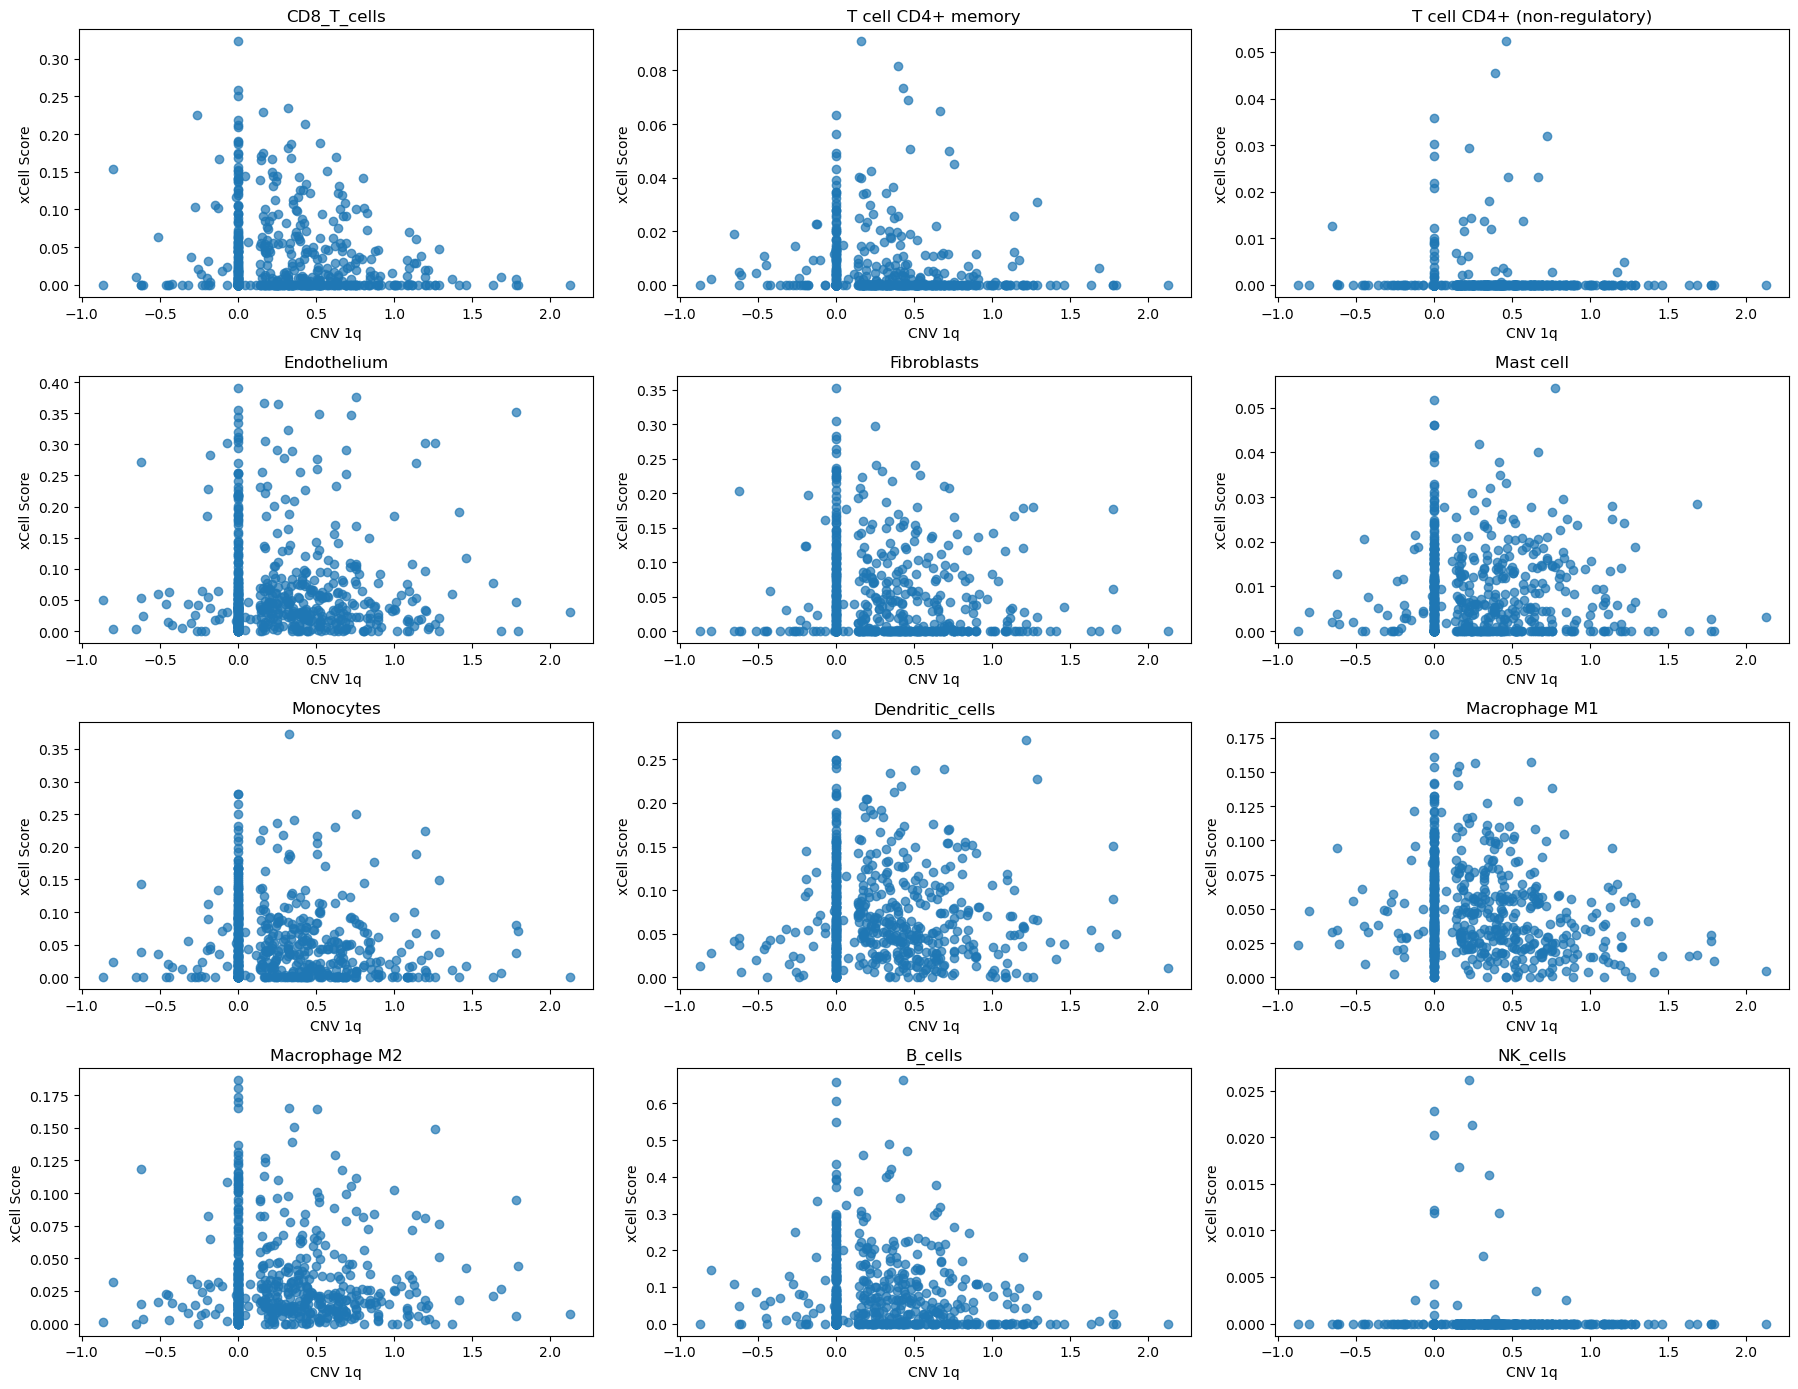

In [23]:
merged_df = xcell_data.join(cnv_data[["Arm1q"]], how="inner")

# Set up 4x3 subplot grid
fig, axes = plt.subplots(4, 3, figsize=(18, 14))
axes = axes.flatten()

# Plot each immune cell
for i, cell in enumerate(selected_cells):
    ax = axes[i]
    ax.scatter(merged_df["Arm1q"], merged_df[cell], alpha=0.7)
    ax.set_title(cell)
    ax.set_xlabel("CNV 1q")
    ax.set_ylabel("xCell Score")

# Hide any extra subplots if selected_cells < total axes
for j in range(len(selected_cells), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

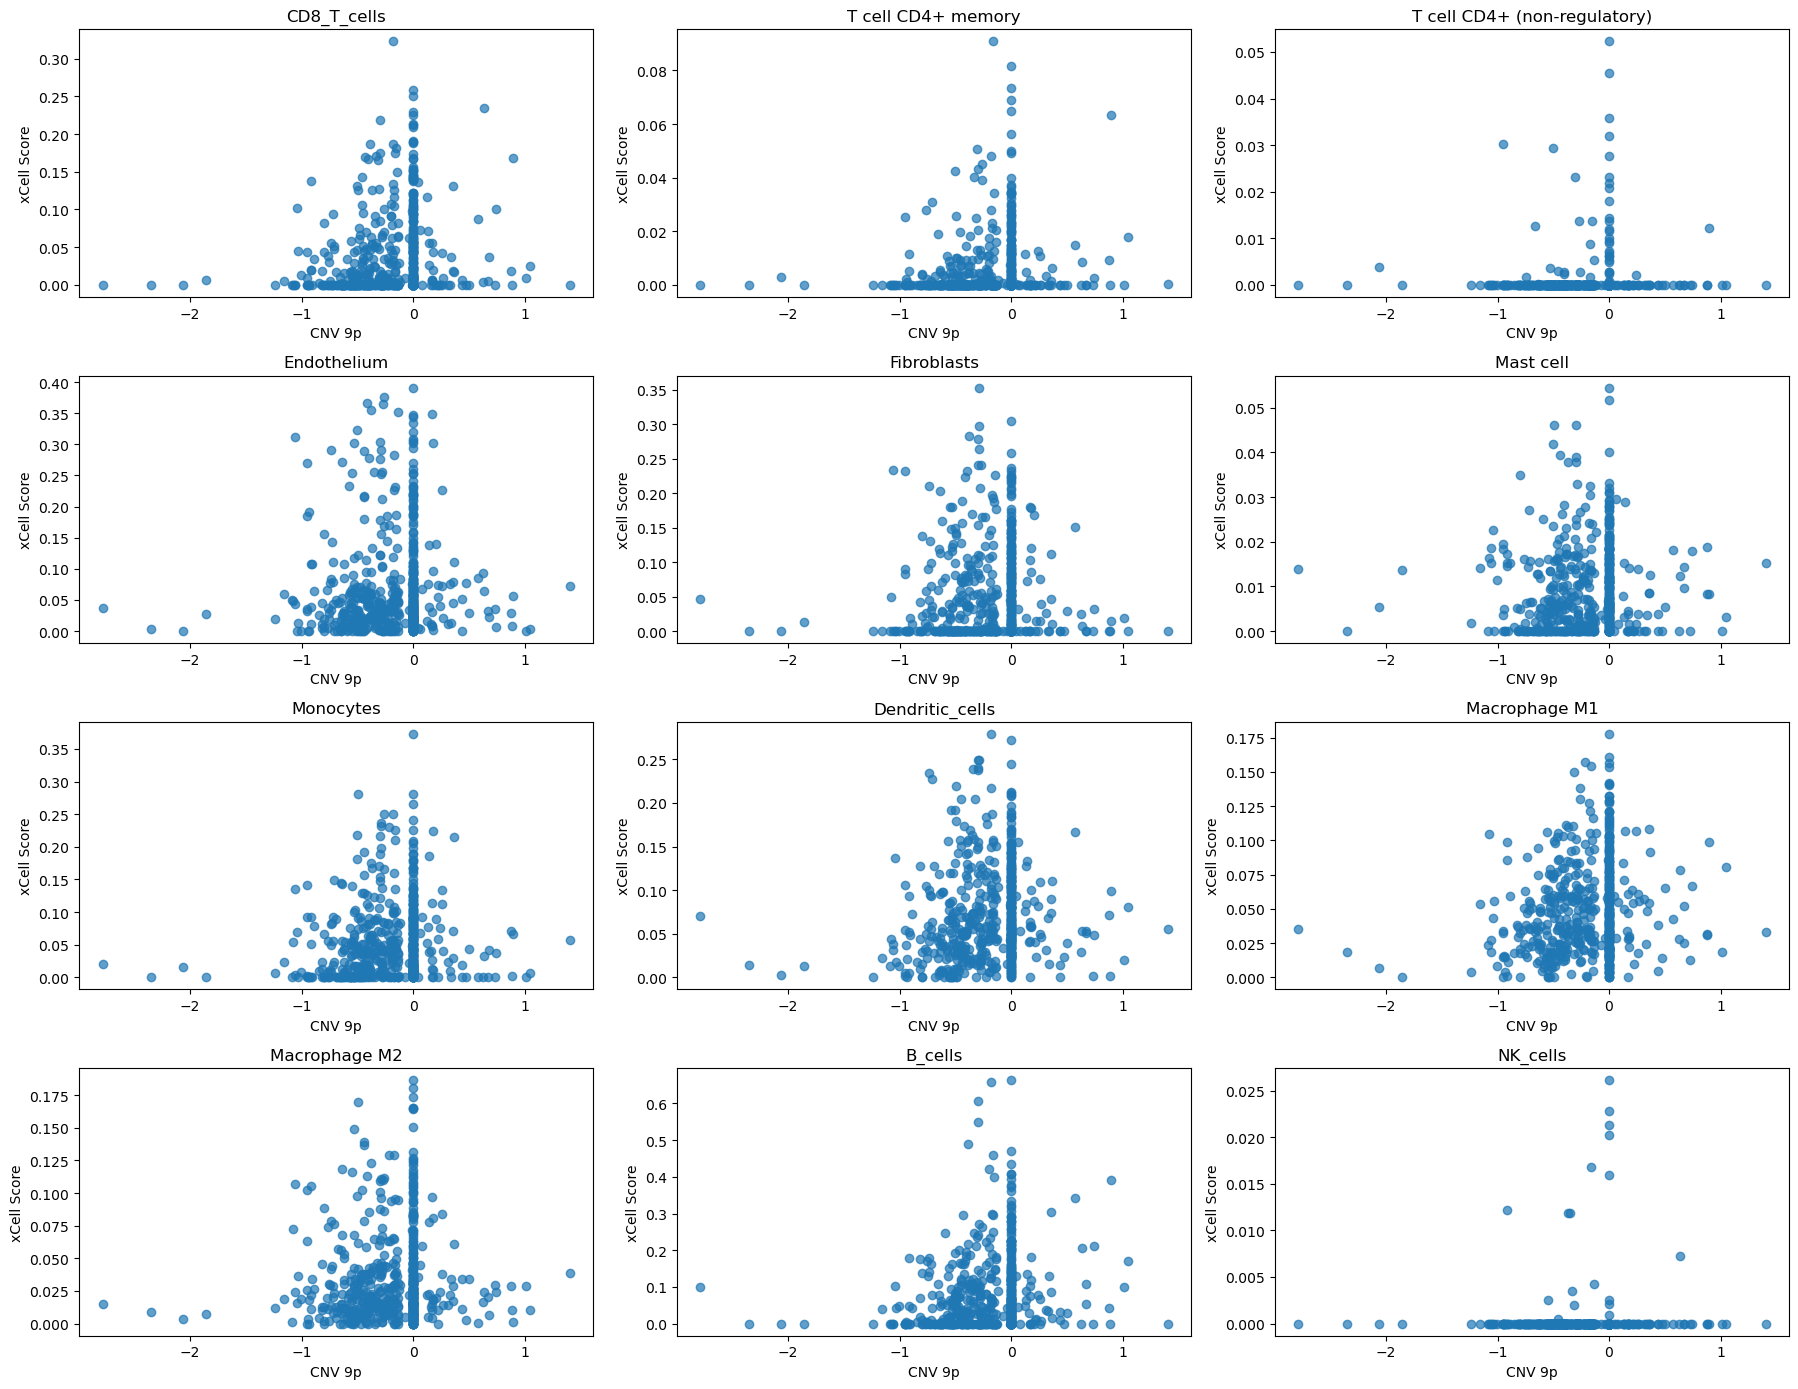

In [24]:
merged_df = xcell_data.join(cnv_data[["Arm9p"]], how="inner")

# Set up 4x3 subplot grid
fig, axes = plt.subplots(4, 3, figsize=(18, 14))
axes = axes.flatten()

# Plot each immune cell
for i, cell in enumerate(selected_cells):
    ax = axes[i]
    ax.scatter(merged_df["Arm9p"], merged_df[cell], alpha=0.7)
    ax.set_title(cell)
    ax.set_xlabel("CNV 9p")
    ax.set_ylabel("xCell Score")

# Hide any extra subplots if selected_cells < total axes
for j in range(len(selected_cells), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [18]:
### Automatically compute thresholds based on quartiles
threshold_gain_1q = cnv_data["Arm1q"].quantile(0.75)  # Top 25% as Gain
threshold_loss_1q = cnv_data["Arm1q"].quantile(0.25)  # Bottom 25% as Loss

threshold_gain_9p = cnv_data["Arm9p"].quantile(0.75)  # Top 25% as Gain
threshold_loss_9p = cnv_data["Arm9p"].quantile(0.25)  # Bottom 25% as Loss

# Classify Arm1q (automatic)
cnv_data["Auto_CNV_Category_1q"] = "Neutral"
cnv_data.loc[cnv_data["Arm1q"] >= threshold_gain_1q, "Auto_CNV_Category_1q"] = "Gain"
cnv_data.loc[cnv_data["Arm1q"] <= threshold_loss_1q, "Auto_CNV_Category_1q"] = "Loss"

# Classify Arm9p (automatic)
cnv_data["Auto_CNV_Category_9p"] = "Neutral"
cnv_data.loc[cnv_data["Arm9p"] >= threshold_gain_9p, "Auto_CNV_Category_9p"] = "Gain"
cnv_data.loc[cnv_data["Arm9p"] <= threshold_loss_9p, "Auto_CNV_Category_9p"] = "Loss"


### Manual threshold classification
manual_gain_threshold = 0.2 
manual_loss_threshold = -0.2 

# Classify Arm1q (manual)
cnv_data["1q_category"] = "Neutral"
cnv_data.loc[cnv_data["Arm1q"] > manual_gain_threshold, "1q_category"] = "Gain"
cnv_data.loc[cnv_data["Arm1q"] < manual_loss_threshold, "1q_category"] = "Loss"

# Classify Arm9p (manual)
cnv_data["Manual_CNV_Category_9p"] = "Neutral"
cnv_data.loc[cnv_data["Arm9p"] > manual_gain_threshold, "Manual_CNV_Category_9p"] = "Gain"
cnv_data.loc[cnv_data["Arm9p"] < manual_loss_threshold, "9p_category"] = "Loss"


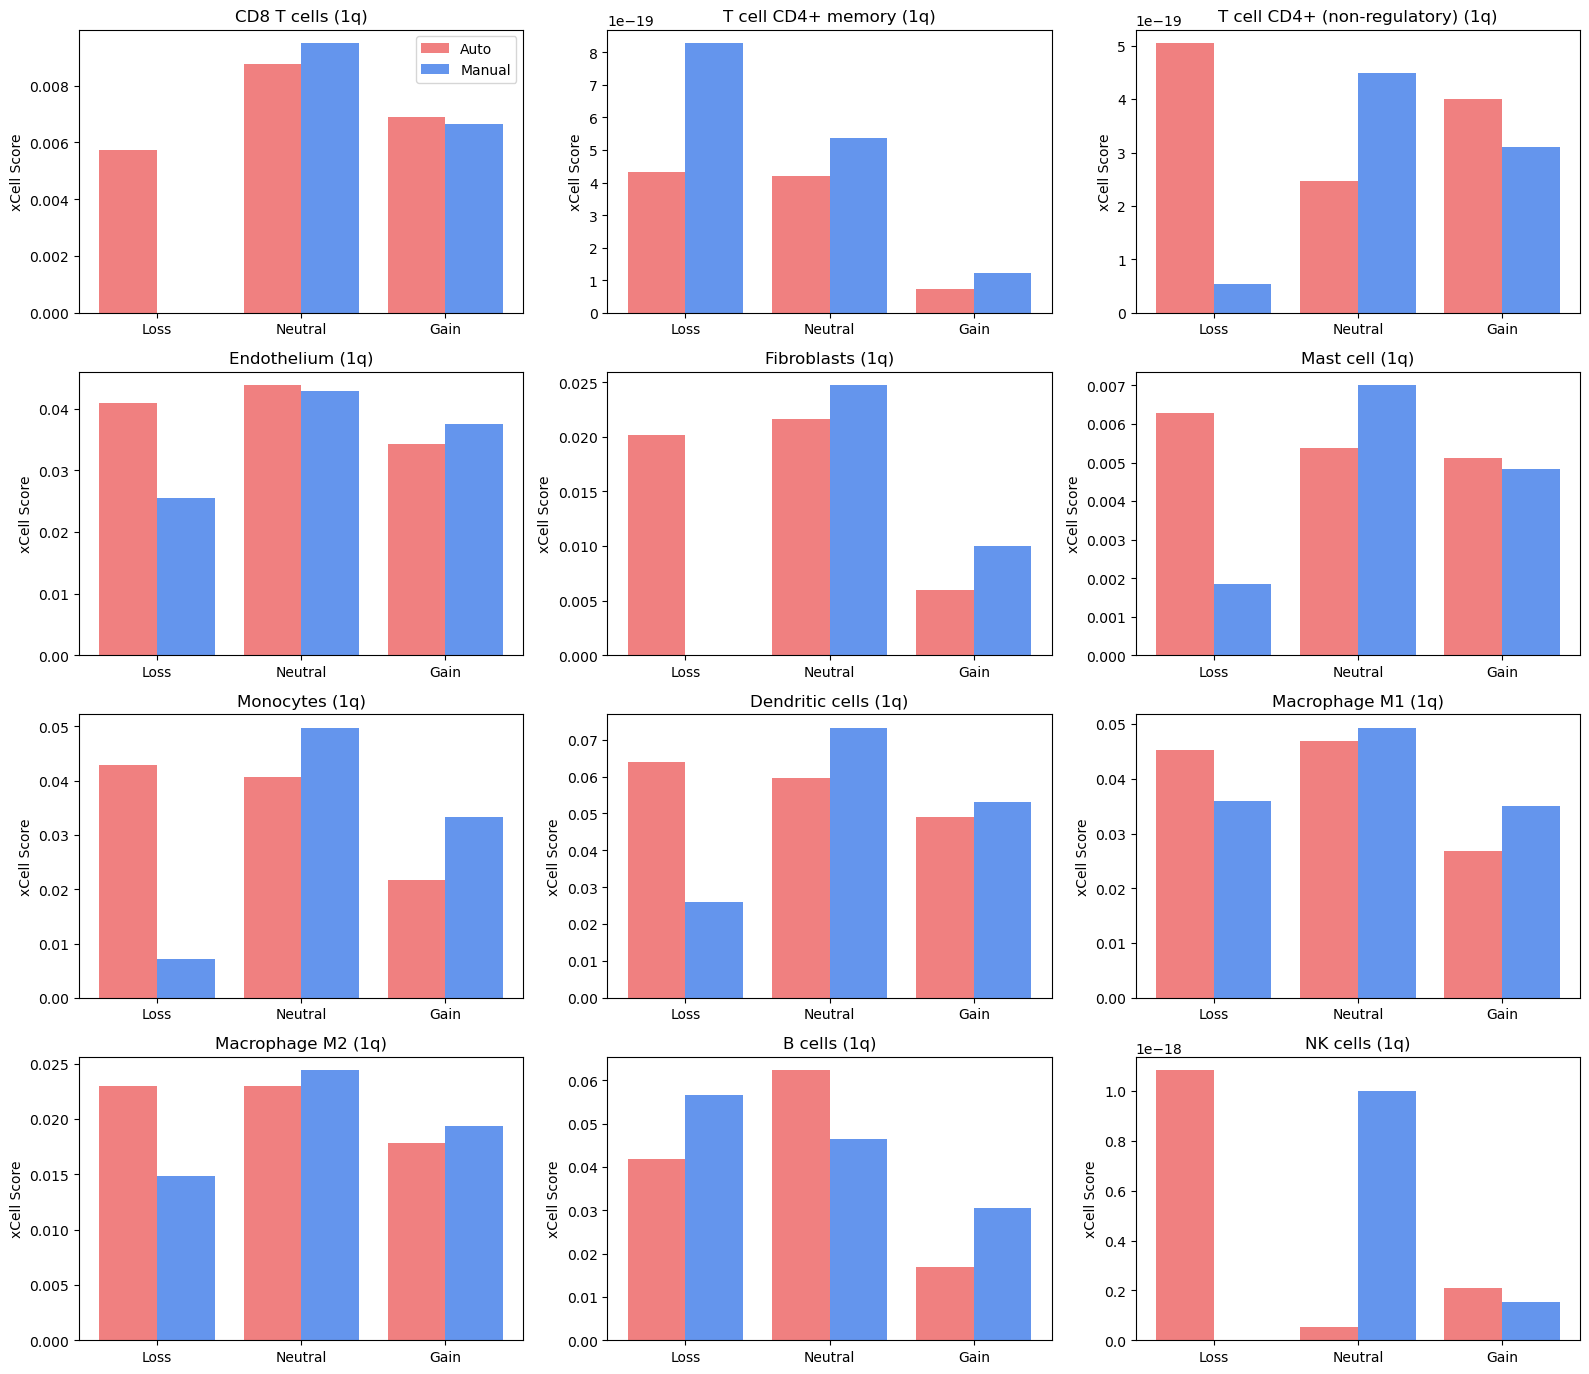

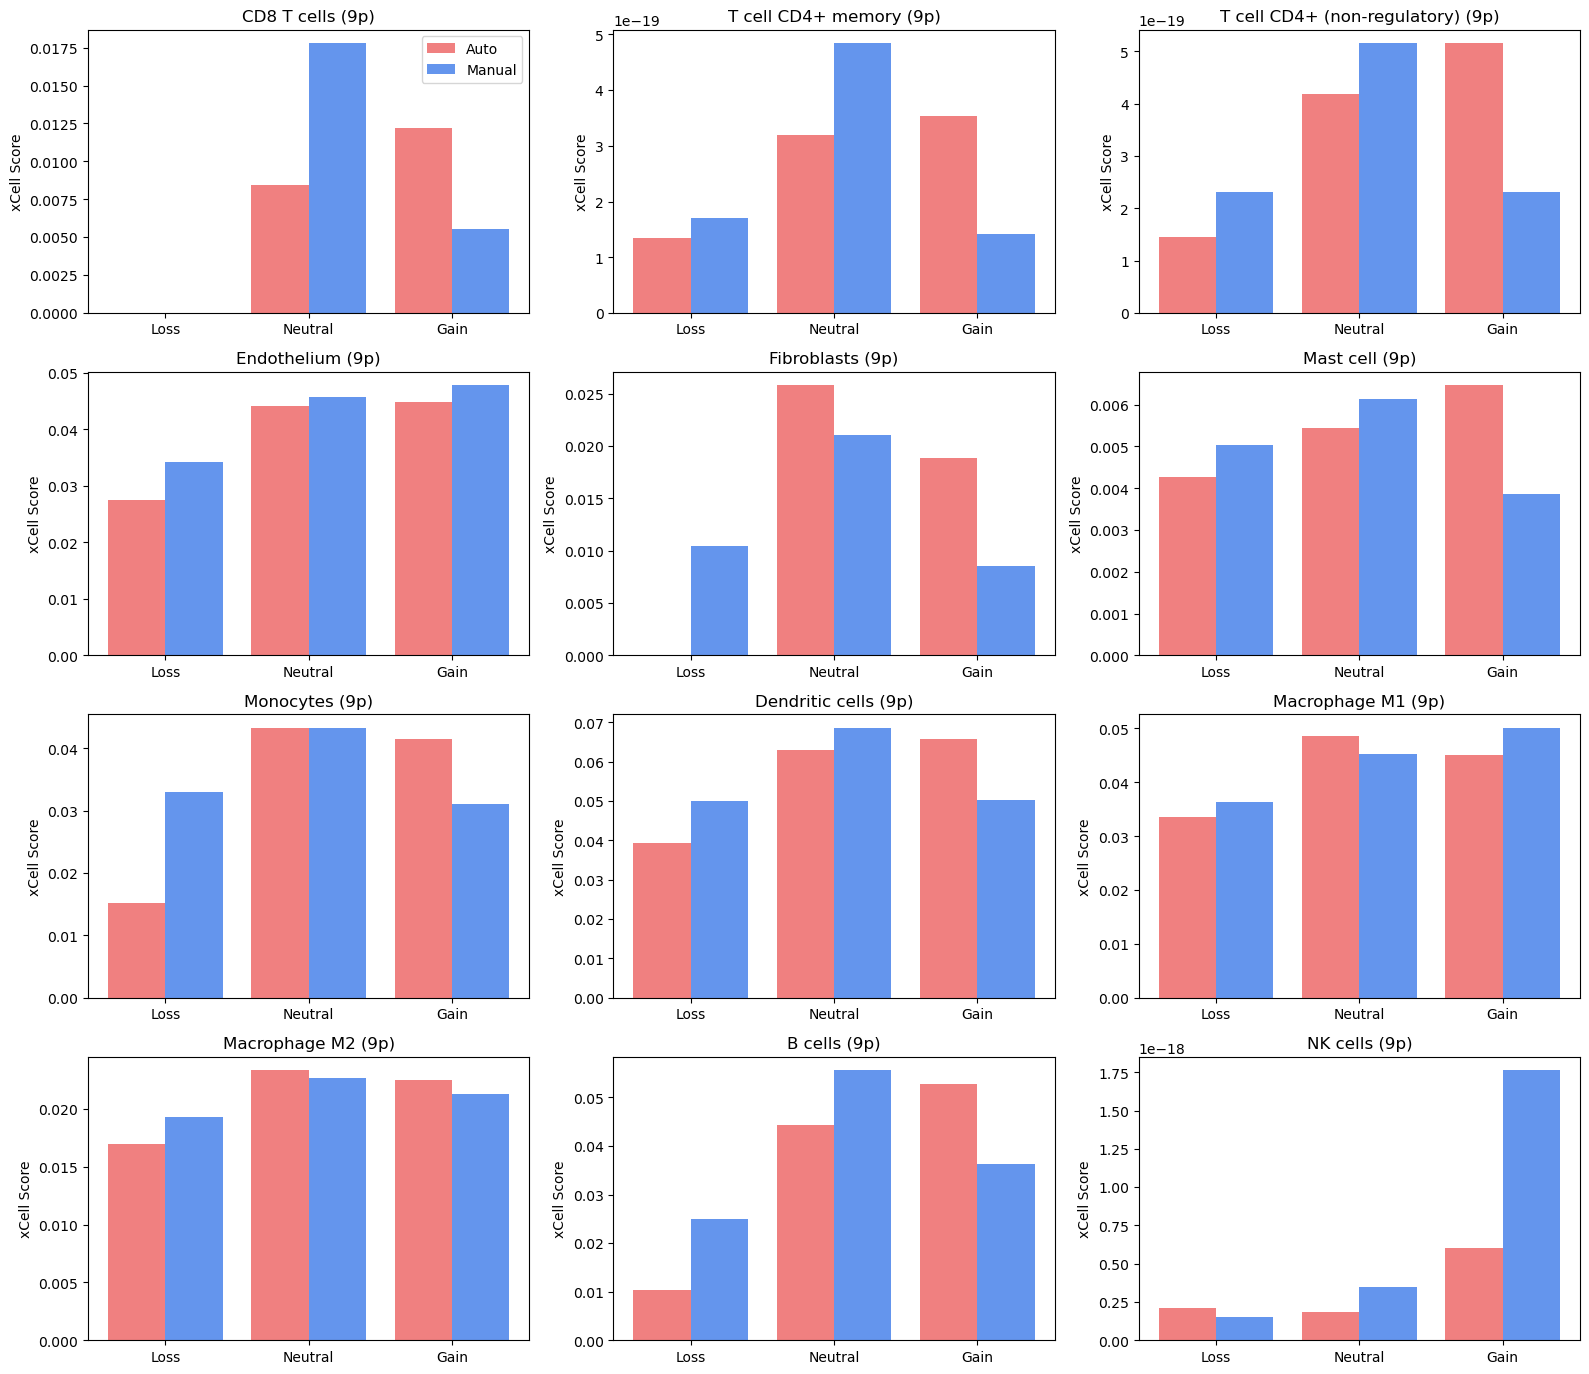

In [19]:
# Join CNV classification (auto and manual) for 1q and 9p
cnv_categories = cnv_data[[
    "Auto_CNV_Category_1q", "1q_category",
    "Auto_CNV_Category_9p", "9p_category"
]]
merged_data = xcell_data.join(cnv_categories, how="inner")

# Define function to compute mean scores
def compute_means(merged_df, category_col):
    return merged_df.groupby(category_col)[selected_cells].median()

# Compute mean immune scores for 1q and 9p using both thresholds
immune_means_1q_auto = compute_means(merged_data, "Auto_CNV_Category_1q")
immune_means_1q_manual = compute_means(merged_data, "1q_category")

immune_means_9p_auto = compute_means(merged_data, "Auto_CNV_Category_9p")
immune_means_9p_manual = compute_means(merged_data, "9p_category")

# CNV colors for bar charts
cnv_colors = {"Loss": "blue", "Neutral": "gray", "Gain": "red"}

### 📊 Plot comparison for Arm1q
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, cell in enumerate(selected_cells):
    ax = axes[i]
    x = range(3)
    
    # Data for auto and manual
    auto_vals = immune_means_1q_auto.reindex(["Loss", "Neutral", "Gain"]).get(cell, [0, 0, 0])
    manual_vals = immune_means_1q_manual.reindex(["Loss", "Neutral", "Gain"]).get(cell, [0, 0, 0])
    
    ax.bar([xi - 0.2 for xi in x], auto_vals, width=0.4, color="lightcoral", label="Auto", align='center')
    ax.bar([xi + 0.2 for xi in x], manual_vals, width=0.4, color="cornflowerblue", label="Manual", align='center')
    
    ax.set_xticks(x)
    ax.set_xticklabels(["Loss", "Neutral", "Gain"])
    ax.set_title(f"{cell.replace('_', ' ')} (1q)")
    ax.set_ylabel("xCell Score")

axes[0].legend()
plt.tight_layout()
plt.show()

### 📊 Plot comparison for Arm9p
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, cell in enumerate(selected_cells):
    ax = axes[i]
    x = range(3)
    
    # Data for auto and manual
    auto_vals = immune_means_9p_auto.reindex(["Loss", "Neutral", "Gain"]).get(cell, [0, 0, 0])
    manual_vals = immune_means_9p_manual.reindex(["Loss", "Neutral", "Gain"]).get(cell, [0, 0, 0])
    
    ax.bar([xi - 0.2 for xi in x], auto_vals, width=0.4, color="lightcoral", label="Auto", align='center')
    ax.bar([xi + 0.2 for xi in x], manual_vals, width=0.4, color="cornflowerblue", label="Manual", align='center')
    
    ax.set_xticks(x)
    ax.set_xticklabels(["Loss", "Neutral", "Gain"])
    ax.set_title(f"{cell.replace('_', ' ')} (9p)")
    ax.set_ylabel("xCell Score")

axes[0].legend()
plt.tight_layout()
plt.show()

/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_72959/4215015198.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x="1q_category", y=cell, palette={"Neutral": "#B8B8B8", "Gain": "#EA6A6A"}, ax=ax)
/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_72959/4215015198.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x="1q_category", y=cell, palette={"Neutral": "#B8B8B8", "Gain": "#EA6A6A"}, ax=ax)
/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_72959/4215015198.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for 

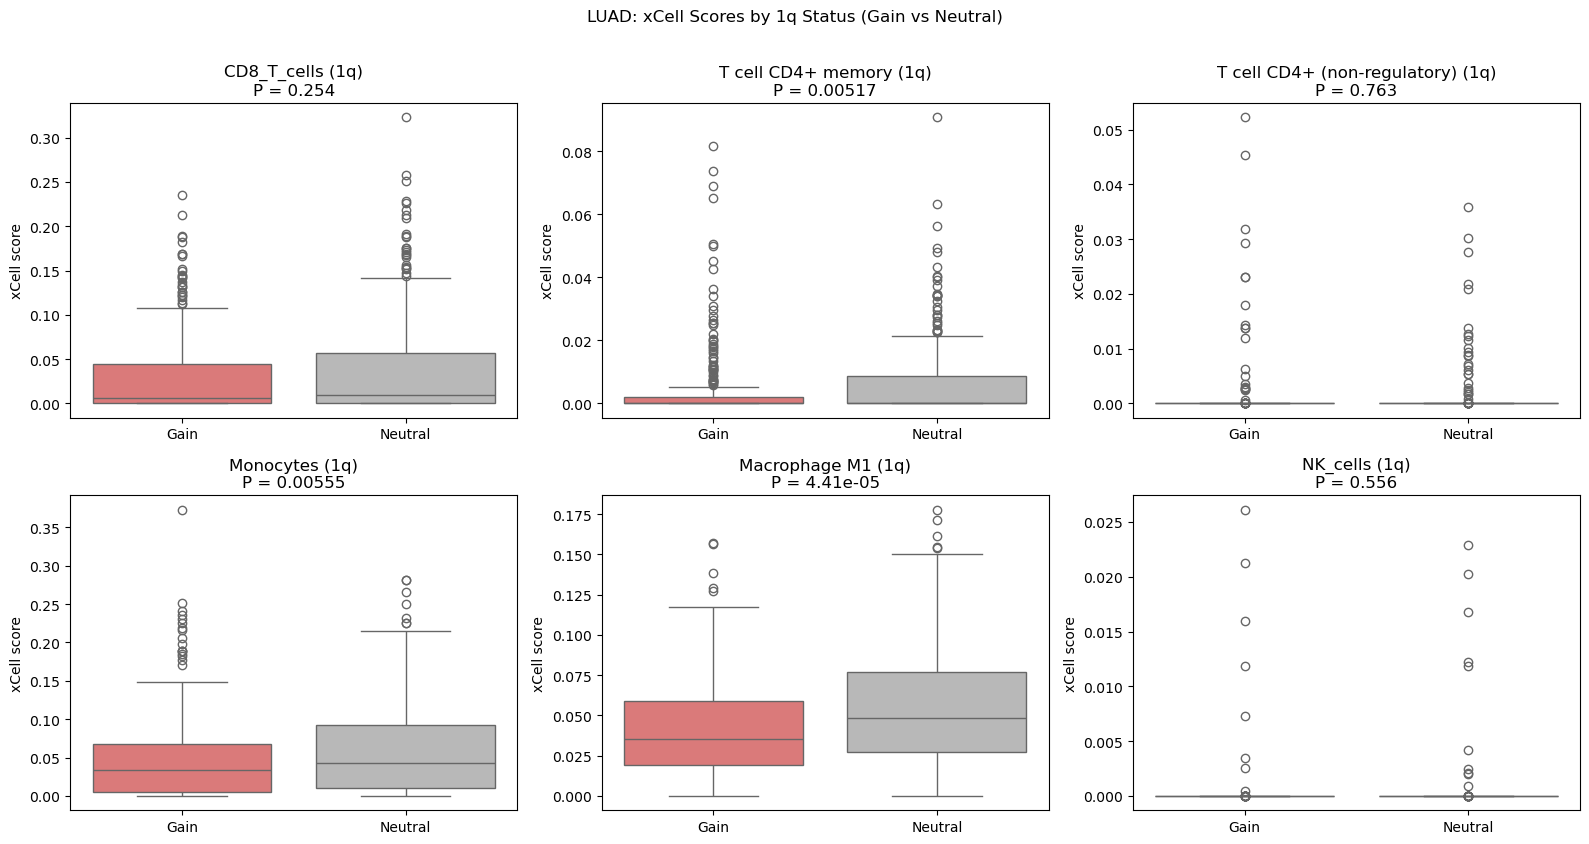

/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_72959/4215015198.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x="9p_category", y=cell, palette={"Neutral": "#B8B8B8", "Loss": "#4F6DB8"}, ax=ax)
/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_72959/4215015198.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x="9p_category", y=cell, palette={"Neutral": "#B8B8B8", "Loss": "#4F6DB8"}, ax=ax)
/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_72959/4215015198.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for 

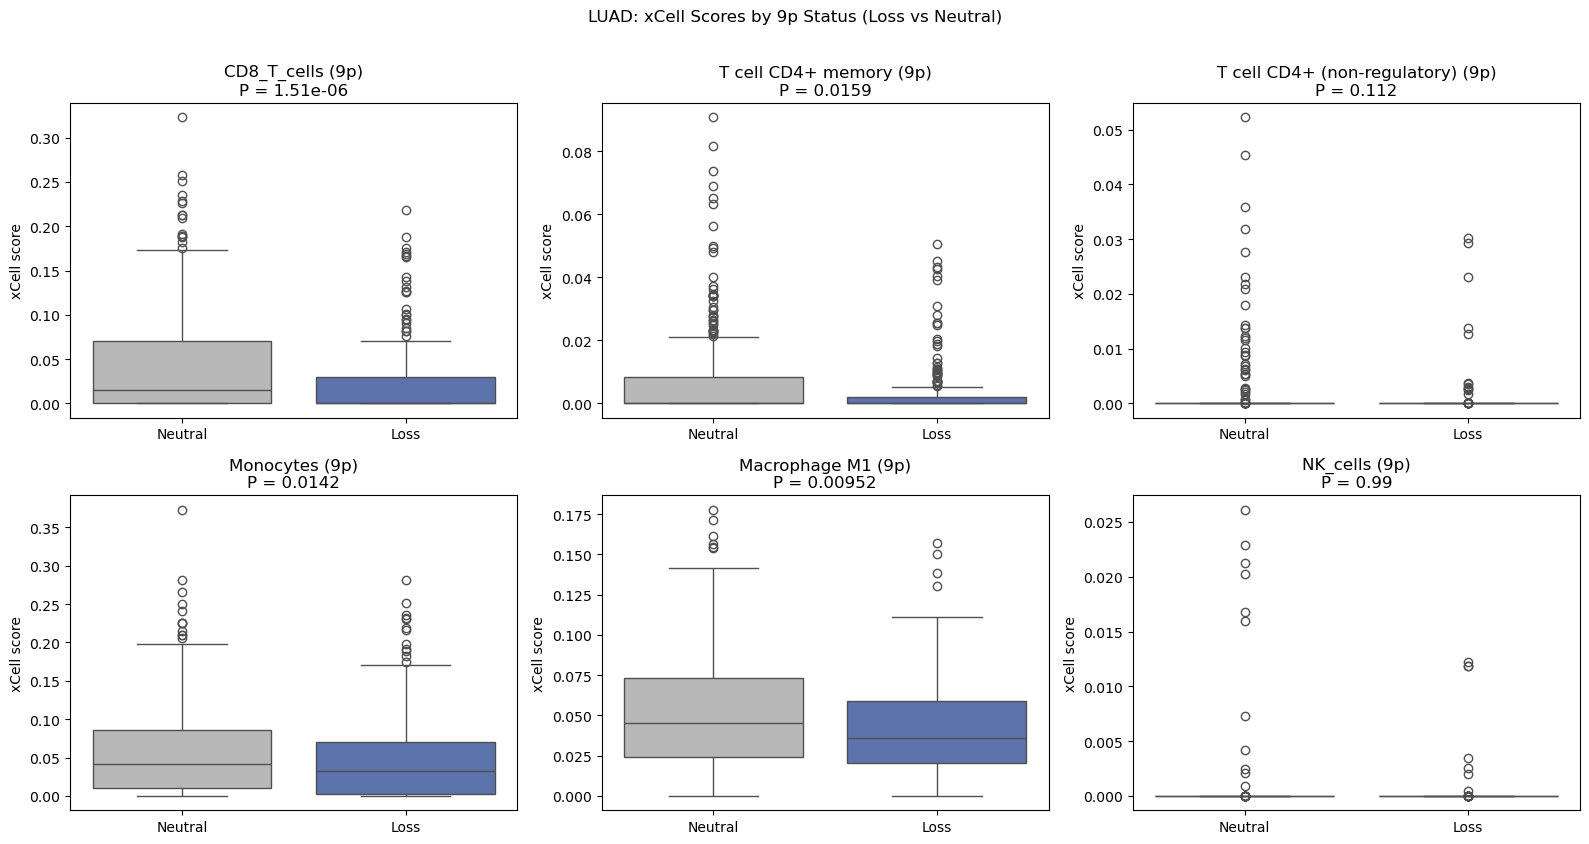

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ranksums 
import seaborn as sns

# Load xCell data (deconvoluted immune scores)
xcell_data = pd.read_csv("LUAD_xcell.tsv", sep="\t", index_col=0)

# Select relevant immune cell types
selected_cells = [
    "CD8_T_cells", "T cell CD4+ memory", "T cell CD4+ (non-regulatory)",  "Monocytes", "Macrophage M1", "NK_cells", 
]
xcell_data = xcell_data[selected_cells]
xcell_data.index = xcell_data.index.str[:-3]  # match sample ID format if needed

# Classify CNV manually
cnv_data["1q_category"] = "Neutral"
cnv_data.loc[cnv_data["Arm1q"] > 0.2, "1q_category"] = "Gain"

cnv_data["9p_category"] = "Neutral"
cnv_data.loc[cnv_data["Arm9p"] < -0.2, "9p_category"] = "Loss"

# Merge
merged = xcell_data.join(cnv_data[["1q_category", "9p_category"]], how="inner")

# Plot 1q Gain vs Neutral
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, cell in enumerate(selected_cells):
    ax = axes[i]
    subset = merged[merged["1q_category"].isin(["Gain", "Neutral"])]
    pval = ranksums(subset[subset["1q_category"] == "Gain"][cell],
                    subset[subset["1q_category"] == "Neutral"][cell]).pvalue
    sns.boxplot(data=subset, x="1q_category", y=cell, palette={"Neutral": "#B8B8B8", "Gain": "#EA6A6A"}, ax=ax)
    ax.set_title(f"{cell} (1q)\nP = {pval:.3g}")
    ax.set_xlabel("")
    ax.set_ylabel("xCell score")

plt.tight_layout()
plt.suptitle("LUAD: xCell Scores by 1q Status (Gain vs Neutral)", y=1.05)
plt.show()

# Plot 9p Loss vs Neutral
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, cell in enumerate(selected_cells):
    ax = axes[i]
    subset = merged[merged["9p_category"].isin(["Loss", "Neutral"])]
    pval = ranksums(subset[subset["9p_category"] == "Loss"][cell],
                    subset[subset["9p_category"] == "Neutral"][cell]).pvalue
    sns.boxplot(data=subset, x="9p_category", y=cell, palette={"Neutral": "#B8B8B8", "Loss": "#4F6DB8"}, ax=ax)
    ax.set_title(f"{cell} (9p)\nP = {pval:.3g}")
    ax.set_xlabel("")
    ax.set_ylabel("xCell score")

plt.tight_layout()
plt.suptitle("LUAD: xCell Scores by 9p Status (Loss vs Neutral)", y=1.05)
plt.show()

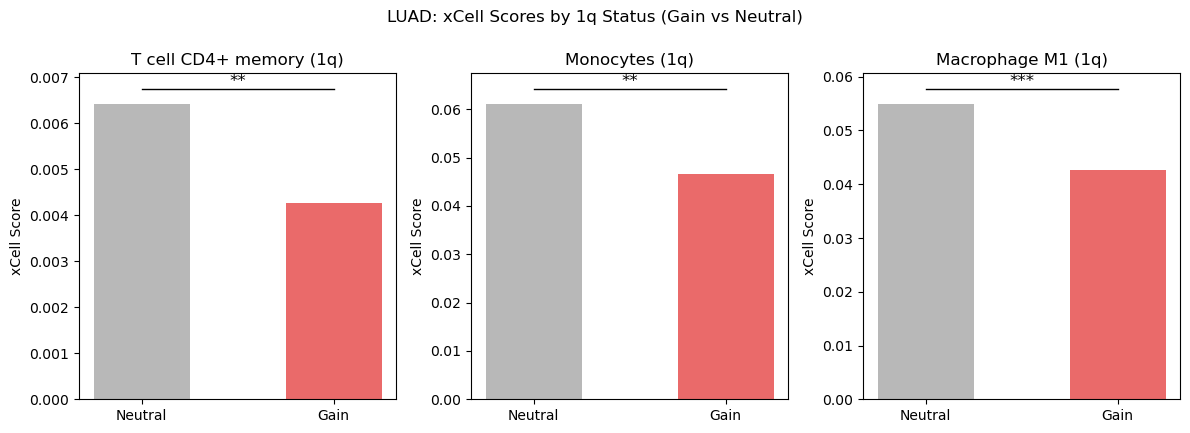

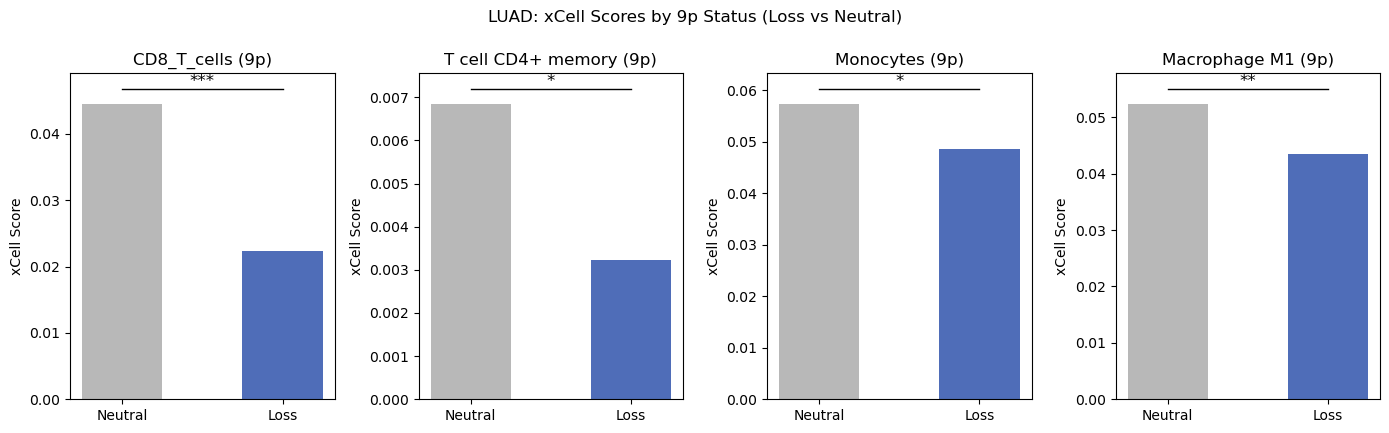

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ranksums

# Load data
xcell_data = pd.read_csv("LUAD_xcell.tsv", sep="\t", index_col=0)
cnv_data = pd.read_csv("LUAD_cnv_table_purity_rescale.txt", sep="\t", index_col=0)

# Format sample names if needed
xcell_data.index = xcell_data.index.str[:-3]

# Cell types
cells_1q = ["T cell CD4+ memory", "Monocytes", "Macrophage M1"]
cells_9p = ["CD8_T_cells", "T cell CD4+ memory", "Monocytes", "Macrophage M1"]

# CNV categories
cnv_data["1q_category"] = "Neutral"
cnv_data.loc[cnv_data["Arm1q"] > 0.2, "1q_category"] = "Gain"
cnv_data["9p_category"] = "Neutral"
cnv_data.loc[cnv_data["Arm9p"] < -0.2, "9p_category"] = "Loss"

# Merge xCell + CNV info
merged = xcell_data.join(cnv_data[["1q_category", "9p_category"]], how="inner")

# ----------- 1q GAIN PLOT -----------
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, cell in enumerate(cells_1q):
    ax = axes[i]
    subset = merged[merged["1q_category"].isin(["Gain", "Neutral"])]
    means = subset.groupby("1q_category")[cell].mean().reindex(["Neutral", "Gain"])
    pval = ranksums(subset[subset["1q_category"] == "Gain"][cell],
                    subset[subset["1q_category"] == "Neutral"][cell]).pvalue
    
    # Plot bars
    ax.bar(["Neutral", "Gain"], means, color=["#B8B8B8", "#EA6A6A"], width=0.5)
    
    # Add significance stars
    if pval < 0.001:
        star = '***'
    elif pval < 0.01:
        star = '**'
    elif pval < 0.05:
        star = '*'
    else:
        star = 'ns'
    
    y_max = max(means) * 1.05
    ax.plot([0, 1], [y_max, y_max], color='black', lw=1)
    ax.text(0.5, y_max * 1.01, star, ha='center', fontsize=12)
    
    ax.set_title(f"{cell} (1q)")
    ax.set_ylabel("xCell Score")
    ax.set_xlabel("")

plt.tight_layout()
plt.suptitle("LUAD: xCell Scores by 1q Status (Gain vs Neutral)", y=1.07)
plt.show()


# ----------- 9p LOSS PLOT -----------
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i, cell in enumerate(cells_9p):
    ax = axes[i]
    subset = merged[merged["9p_category"].isin(["Loss", "Neutral"])]
    means = subset.groupby("9p_category")[cell].mean().reindex(["Neutral", "Loss"])
    pval = ranksums(subset[subset["9p_category"] == "Loss"][cell],
                    subset[subset["9p_category"] == "Neutral"][cell]).pvalue
    
    # Plot bars
    ax.bar(["Neutral", "Loss"], means, color=["#B8B8B8", "#4F6DB8"], width=0.5)
    
    # Add significance stars
    if pval < 0.001:
        star = '***'
    elif pval < 0.01:
        star = '**'
    elif pval < 0.05:
        star = '*'
    else:
        star = 'ns'
    
    y_max = max(means) * 1.05
    ax.plot([0, 1], [y_max, y_max], color='black', lw=1)
    ax.text(0.5, y_max * 1.01, star, ha='center', fontsize=12)
    
    ax.set_title(f"{cell} (9p)")
    ax.set_ylabel("xCell Score")
    ax.set_xlabel("")

plt.tight_layout()
plt.suptitle("LUAD: xCell Scores by 9p Status (Loss vs Neutral)", y=1.07)
plt.show()

/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_77429/2847109614.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_data,
/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_77429/2847109614.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_data,
/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_77429/2847109614.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_data,
/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_77429/2847109614.py:33: FutureWarning: 

Passin

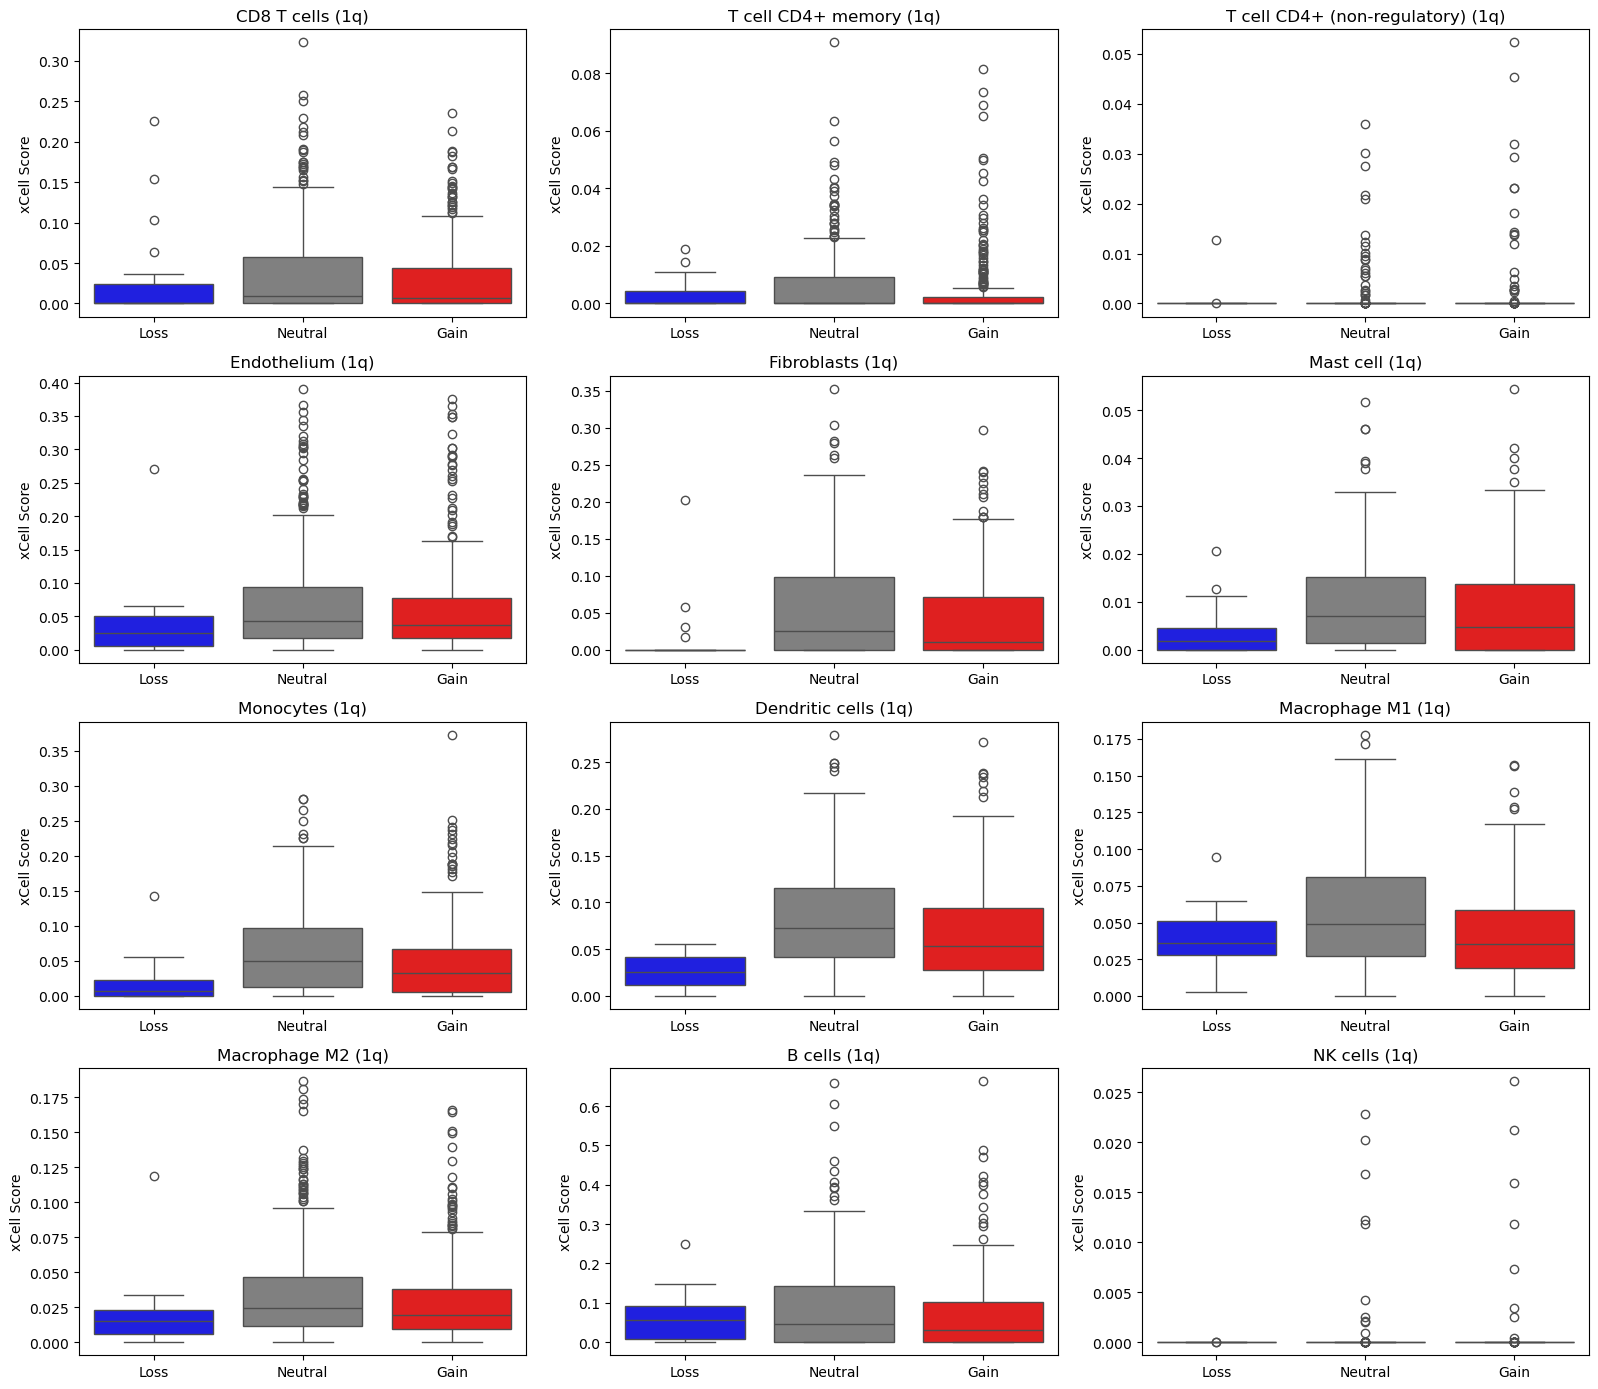

/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_77429/2847109614.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_data,
/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_77429/2847109614.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_data,
/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_77429/2847109614.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_data,
/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_77429/2847109614.py:58: FutureWarning: 

Passin

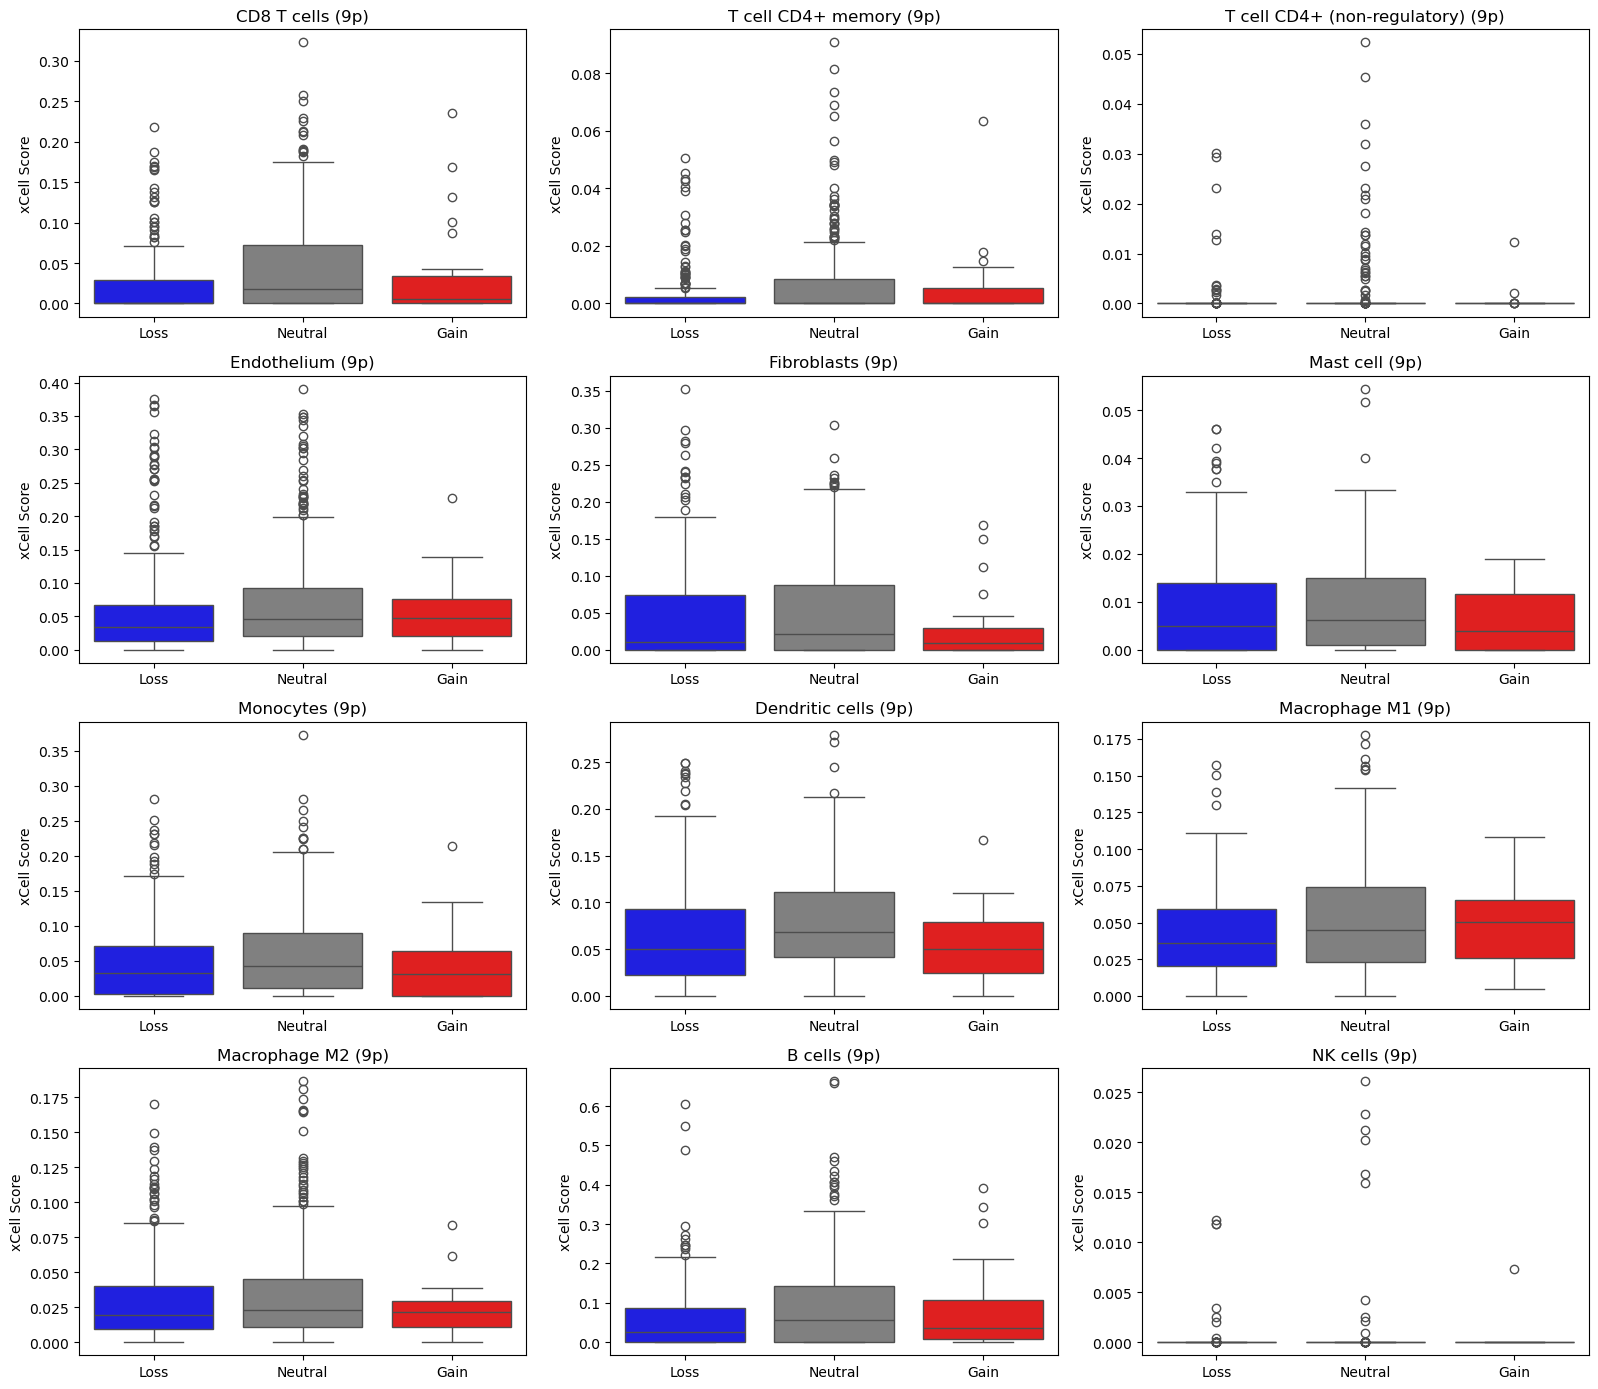

In [8]:
# --- Manual CNV classification (only using manual thresholds) ---
manual_gain_threshold = 0.2 
manual_loss_threshold = -0.2 

# For Arm1q
cnv_data["1q_category"] = "Neutral"
cnv_data.loc[cnv_data["Arm1q"] > manual_gain_threshold, "1q_category"] = "Gain"
cnv_data.loc[cnv_data["Arm1q"] < manual_loss_threshold, "1q_category"] = "Loss"

# For Arm9p
cnv_data["Manual_CNV_Category_9p"] = "Neutral"
cnv_data.loc[cnv_data["Arm9p"] > manual_gain_threshold, "Manual_CNV_Category_9p"] = "Gain"
cnv_data.loc[cnv_data["Arm9p"] < manual_loss_threshold, "Manual_CNV_Category_9p"] = "Loss"

# --- Merge xCell scores with CNV classification ---
# Here we join the manual classification columns for Arm1q and Arm9p to the xCell data.
cnv_categories = cnv_data[["1q_category", "Manual_CNV_Category_9p"]]
merged_data = xcell_data.join(cnv_categories, how="inner")

# Define CNV colors
cnv_colors = {"Loss": "blue", "Neutral": "gray", "Gain": "red"}

# --- Plot using box plots instead of bar plots ---
# We'll create two sets of plots: one for Arm1q and one for Arm9p.

### Plot for Arm1q using boxplots ###
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, cell in enumerate(selected_cells):
    ax = axes[i]
    # Use the raw xCell scores from merged_data and the 1q_category for grouping
    sns.boxplot(data=merged_data, 
                x="1q_category", 
                y=cell, 
                order=["Loss", "Neutral", "Gain"],
                palette=cnv_colors,
                ax=ax)
    ax.set_title(f"{cell.replace('_', ' ')} (1q)")
    ax.set_xlabel("")
    ax.set_ylabel("xCell Score")

# Remove any extra subplots if selected_cells < total subplots
for j in range(len(selected_cells), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Plot for Arm9p using boxplots ###
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, cell in enumerate(selected_cells):
    ax = axes[i]
    # Use the raw xCell scores and the Manual_CNV_Category_9p for grouping
    sns.boxplot(data=merged_data, 
                x="Manual_CNV_Category_9p", 
                y=cell, 
                order=["Loss", "Neutral", "Gain"],
                palette=cnv_colors,
                ax=ax)
    ax.set_title(f"{cell.replace('_', ' ')} (9p)")
    ax.set_xlabel("")
    ax.set_ylabel("xCell Score")

for j in range(len(selected_cells), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [9]:
######### Immune score (IS) after taking consideration of aneuplody score 
IS_data = pd.read_csv("/Users/annabelshinichen/Desktop/SchoolWork/MSBMI/Davoli_lab/bulk seq/scores/regression_results_continous.csv", sep=",",encoding="utf-8-sig",header=0)
print(IS_data.head())

  TumorType  B_cells.Coefficients  B_cells.Std_Error  B_cells.Z_val  \
0       ACC             -1.540243           2.996415      -0.514029   
1       ACC             -0.075194           0.706033      -0.106502   
2       ACC             -0.805285           2.553938      -0.315311   
3       ACC             -0.028387           0.703916      -0.040327   
4       ACC             -1.921086           3.301866      -0.581819   

   B_cells.P_val B_cells.Cytoband B_cells.Event B_cells.Chromosome  \
0       0.607232          1p36.33          Gain               Chr1   
1       0.915184          1p36.33          Loss               Chr1   
2       0.752525          1p36.32          Gain               Chr1   
3       0.967832          1p36.32          Loss               Chr1   
4       0.560689          1p36.31          Gain               Chr1   

  B_cells.Arm B_cells.ChrArm  ...  CD4_T_cells.ChrArm  \
0           p          Chr1p  ...               Chr1p   
1           p          Chr1p  ...     

Immune cell types to plot: ['B_cells', 'CD8_T_cells', 'Dendritic_cells', 'Endothelium', 'Fibroblasts', 'Macrophage_M1', 'Macrophage_M2', 'Mast_cell', 'Monocytes', 'NK_cells', 'T_cell_CD4_memory', 'T_cell_CD4_naive', 'T_cell_CD4_nonregulatory', 'T_cells', 'Tregs']


/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_77429/1474190057.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Loss', 'Gain'],
/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_77429/1474190057.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Loss', 'Gain'],
/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_77429/1474190057.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Loss', 'Gain'],
/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_77429/1474190057.py:60: FutureWarning: 



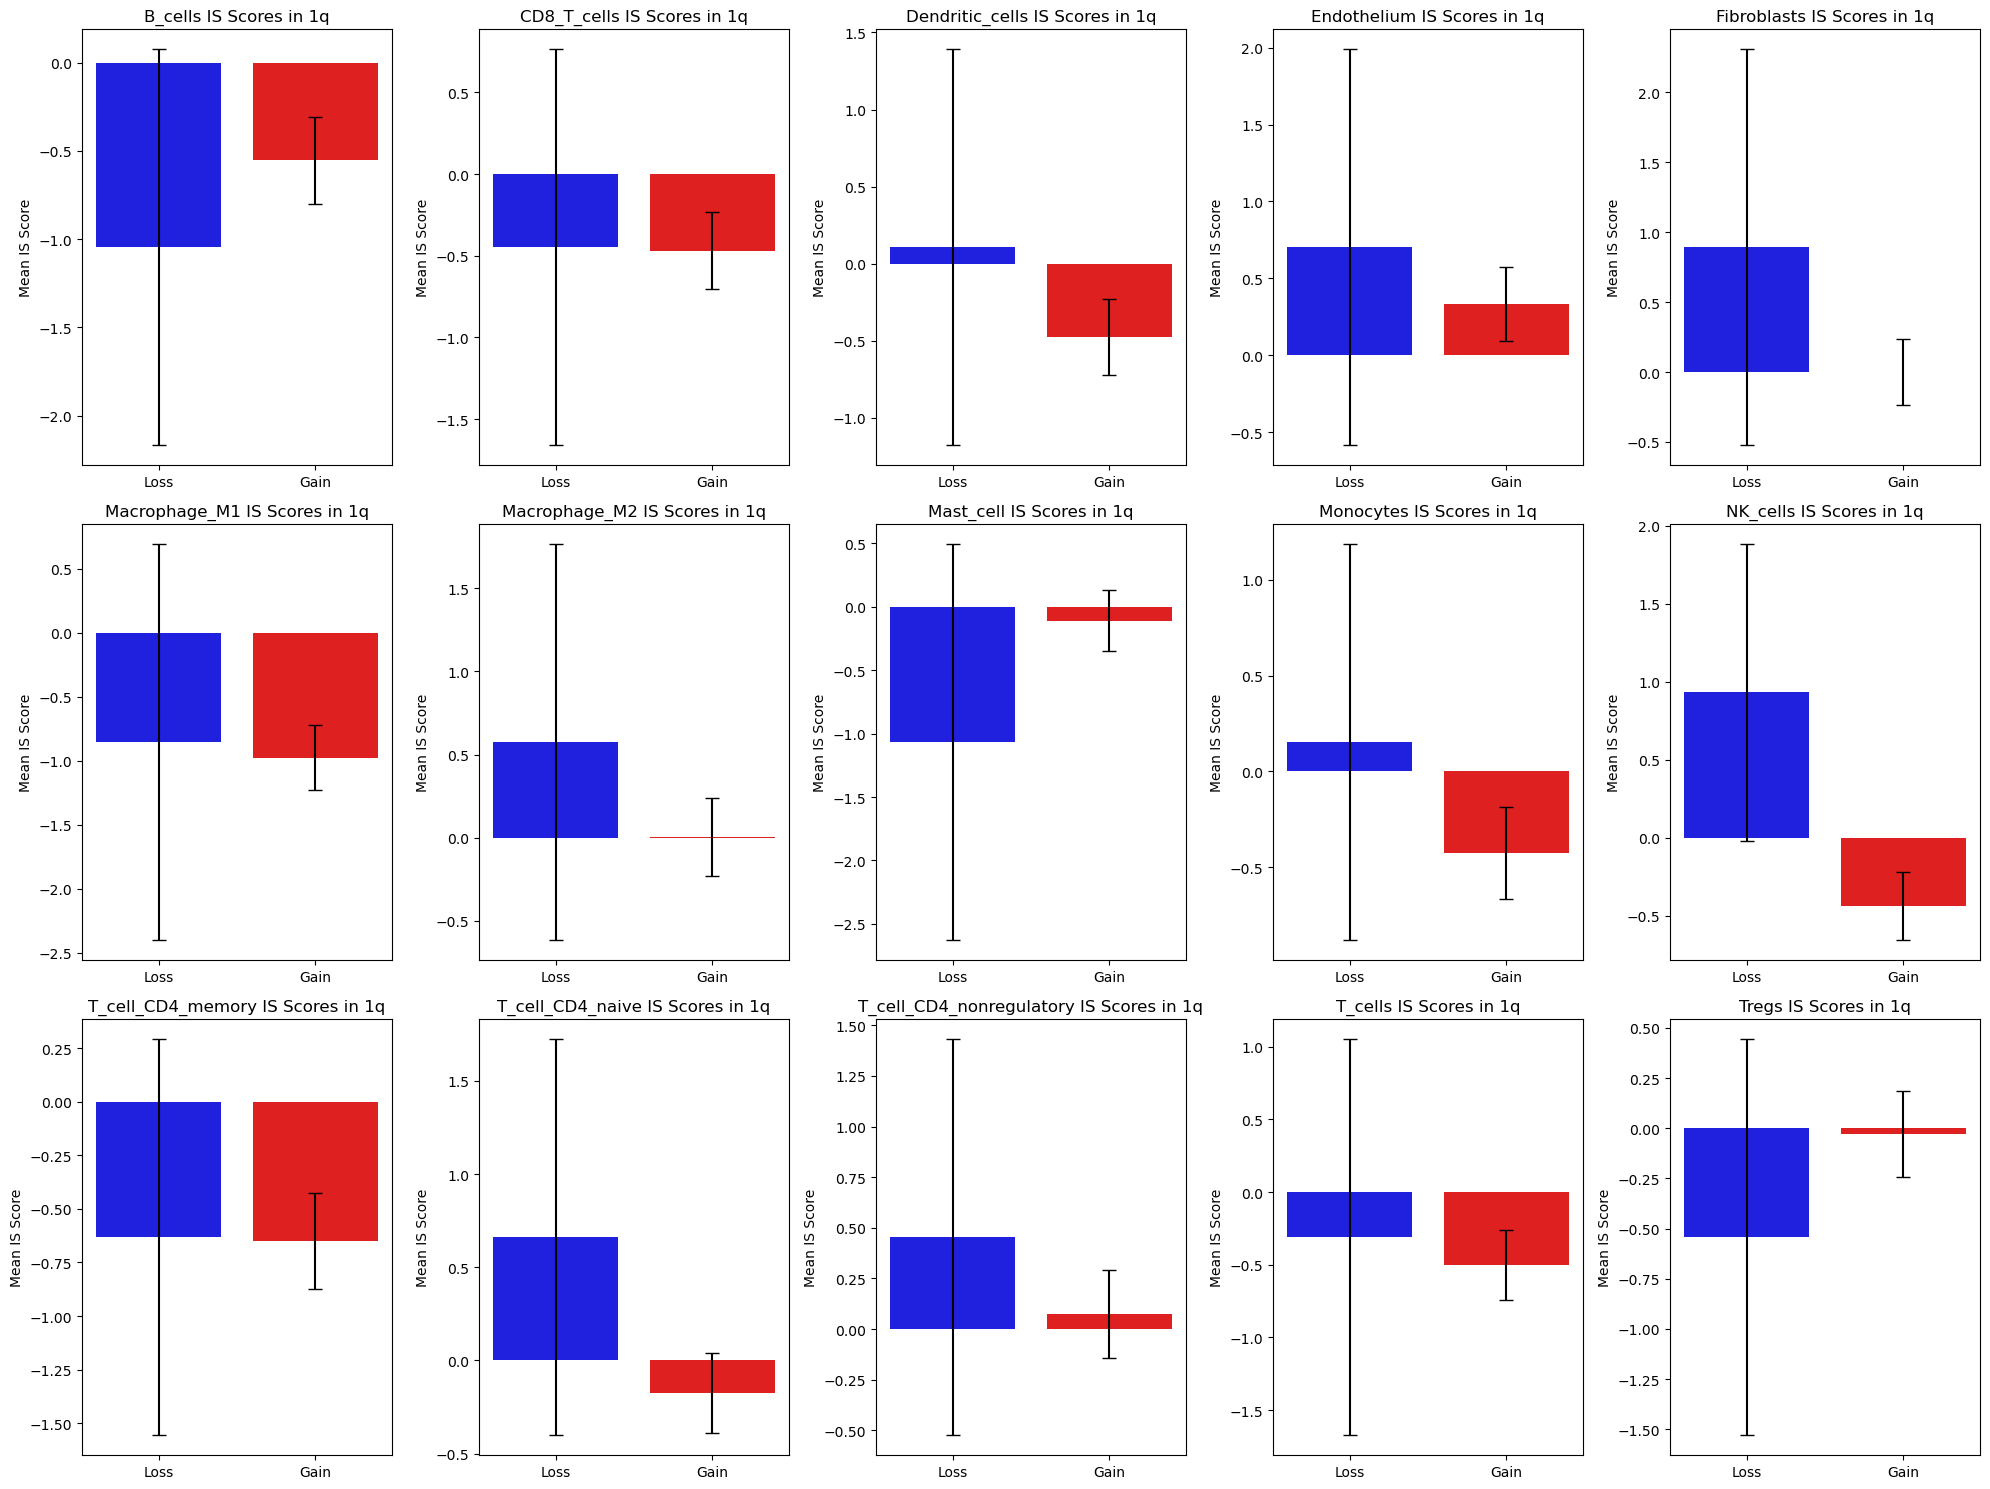

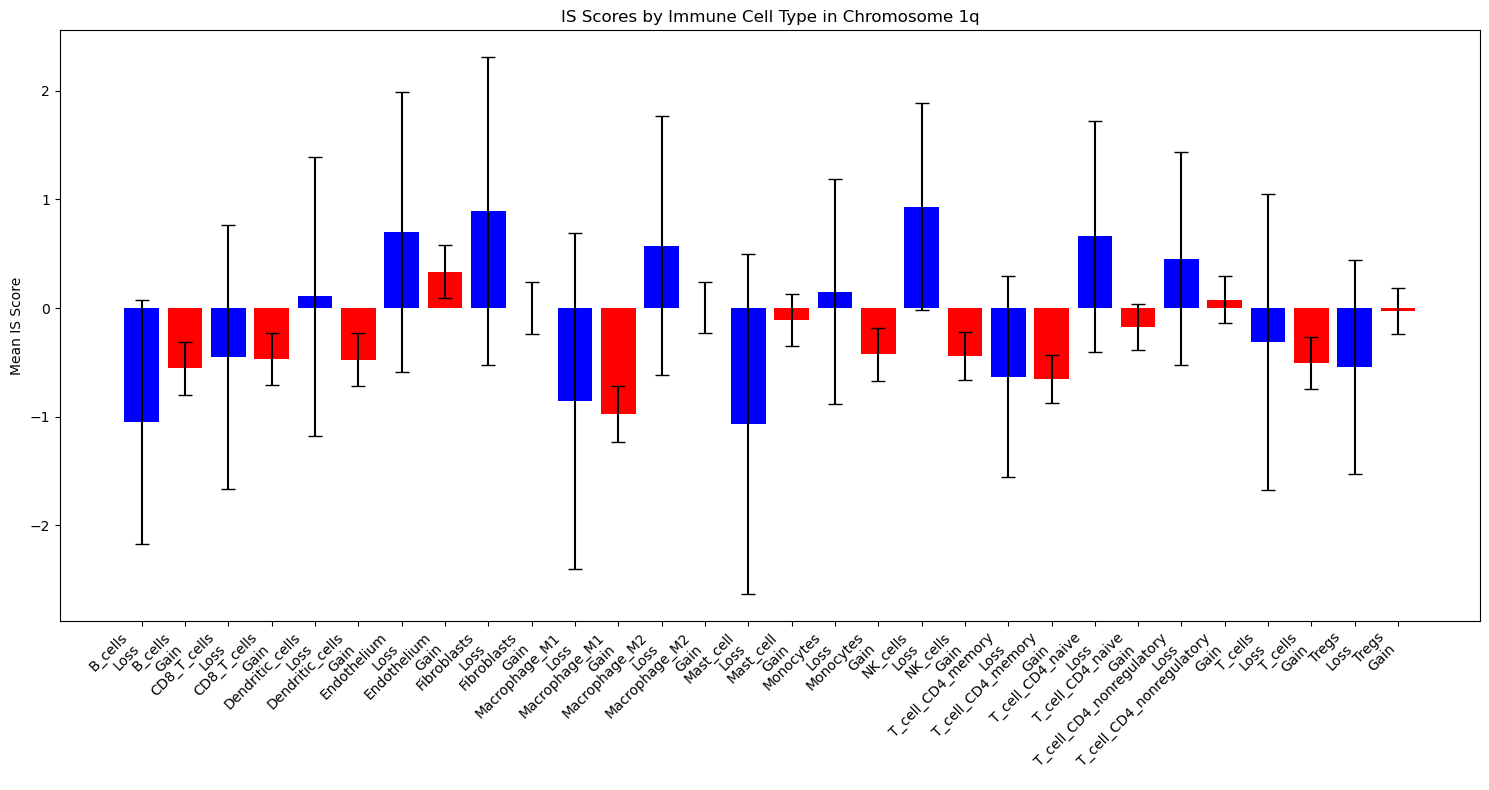

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assume df_LUAD is already loaded, filtered, and cleaned.
# Example:
df_luad = IS_data[IS_data["TumorType"] == "LUAD"]
df_luad.columns = df_luad.columns.str.strip()

# Define the cell types to exclude.
exclude_cells = {"CD4_T_cells", "Eosinophil", "Lymphocytes", "Macrophages", "Neutrophils"}

# Build the list of immune cell types from columns ending with ".Coefficients",
# excluding "TumorType" and the ones in our exclusion list.
immune_cells = sorted(set([col.split('.')[0] for col in df_luad.columns 
                             if col.endswith("Coefficients") 
                             and col.split('.')[0] != "TumorType"
                             and col.split('.')[0] not in exclude_cells]))
print("Immune cell types to plot:", immune_cells)

# Create subplots for each immune cell type using 5 columns and 3 rows.
ncols = 5
nrows = 3
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 15))
axes = axes.ravel()

# Plot for each immune cell type for chromosome arm 1q.
for idx, cell_type in enumerate(immune_cells):
    # Build the column names.
    chrarm_col = f"{cell_type}.ChrArm"
    event_col  = f"{cell_type}.Event"
    coef_col   = f"{cell_type}.Coefficients"
    se_col     = f"{cell_type}.Std_Error"
    
    # Check that required columns exist.
    if not all(col in df_luad.columns for col in [chrarm_col, event_col, coef_col, se_col]):
        continue  # Skip if any column is missing
    
    # Filter rows for 1q events.
    is_1q = df_luad[chrarm_col] == 'Chr1q'
    
    # Get coefficients and events for 1q.
    is_scores = df_luad.loc[is_1q, coef_col].values
    events = df_luad.loc[is_1q, event_col].values
    # Use the provided standard error column.
    se_values = df_luad.loc[is_1q, se_col].values
    
    if len(is_scores) > 0:
        # Compute mean coefficients for Loss and Gain.
        loss_mean = np.mean(is_scores[events == 'Loss']) if np.any(events == 'Loss') else np.nan
        gain_mean = np.mean(is_scores[events == 'Gain']) if np.any(events == 'Gain') else np.nan
        
        # Compute mean standard error for Loss and Gain using the Std_Error column.
        loss_se = np.mean(df_luad.loc[is_1q & (df_luad[event_col] == 'Loss'), se_col]) if np.any(events == 'Loss') else np.nan
        gain_se = np.mean(df_luad.loc[is_1q & (df_luad[event_col] == 'Gain'), se_col]) if np.any(events == 'Gain') else np.nan
        
        # Create the bar plot for Loss and Gain.
        ax = axes[idx]
        sns.barplot(x=['Loss', 'Gain'], 
                    y=[loss_mean, gain_mean],
                    ax=ax,
                    palette=["blue", "red"])
        ax.set_title(f'{cell_type} IS Scores in 1q')
        ax.set_ylabel('Mean IS Score')
        ax.set_xlabel('')
        # Optionally set y-axis limits if needed:
        # ax.set_ylim(min(loss_mean, gain_mean)-1, max(loss_mean, gain_mean)+1)
        
        # Add error bars for Loss and Gain.
        ax.errorbar(x=[0, 1], 
                    y=[loss_mean, gain_mean],
                    yerr=[loss_se, gain_se],
                    fmt='none', color='black', capsize=5)
    else:
        # Remove the subplot if no data exists for this cell type.
        fig.delaxes(axes[idx])

# Remove any extra empty subplots.
for idx in range(len(immune_cells), len(axes)):
    fig.delaxes(axes[idx])
    
plt.tight_layout()
plt.show()


# Create a summary plot aggregating all immune cell types for 1q (only Loss and Gain)
plt.figure(figsize=(15, 8))
all_means = []
all_stds = []
labels = []

for cell_type in immune_cells:
    chrarm_col = f"{cell_type}.ChrArm"
    event_col  = f"{cell_type}.Event"
    coef_col   = f"{cell_type}.Coefficients"
    se_col     = f"{cell_type}.Std_Error"
    
    if not all(col in df_luad.columns for col in [chrarm_col, event_col, coef_col, se_col]):
        continue
    
    is_1q = df_luad[chrarm_col] == 'Chr1q'
    is_scores = df_luad.loc[is_1q, coef_col].values
    events = df_luad.loc[is_1q, event_col].values
    
    if len(is_scores) > 0:
        loss_mean = np.mean(is_scores[events == 'Loss']) if np.any(events == 'Loss') else np.nan
        gain_mean = np.mean(is_scores[events == 'Gain']) if np.any(events == 'Gain') else np.nan
        
        loss_se = np.mean(df_luad.loc[is_1q & (df_luad[event_col] == 'Loss'), se_col]) if np.any(events == 'Loss') else np.nan
        gain_se = np.mean(df_luad.loc[is_1q & (df_luad[event_col] == 'Gain'), se_col]) if np.any(events == 'Gain') else np.nan
        
        all_means.extend([loss_mean, gain_mean])
        all_stds.extend([loss_se, gain_se])
        labels.extend([f'{cell_type}\nLoss', f'{cell_type}\nGain'])

x = np.arange(len(labels))
plt.bar(x, all_means, yerr=all_stds, capsize=5, color=["blue", "red"] * (len(labels)//2))
plt.xticks(x, labels, rotation=45, ha='right')
plt.ylabel('Mean IS Score')
plt.title('IS Scores by Immune Cell Type in Chromosome 1q')
plt.tight_layout()
plt.savefig('IS_scores_immune_cells_1q_summary.png', dpi=300, bbox_inches='tight')
plt.show()


Immune cell types to plot: ['B_cells', 'CD8_T_cells', 'Dendritic_cells', 'Endothelium', 'Fibroblasts', 'Macrophage_M1', 'Macrophage_M2', 'Mast_cell', 'Monocytes', 'NK_cells', 'T_cell_CD4_memory', 'T_cell_CD4_naive', 'T_cell_CD4_nonregulatory', 'T_cells', 'Tregs']


/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_77429/2897465025.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Loss', 'Gain'],
/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_77429/2897465025.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Loss', 'Gain'],
/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_77429/2897465025.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Loss', 'Gain'],
/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_77429/2897465025.py:60: FutureWarning: 



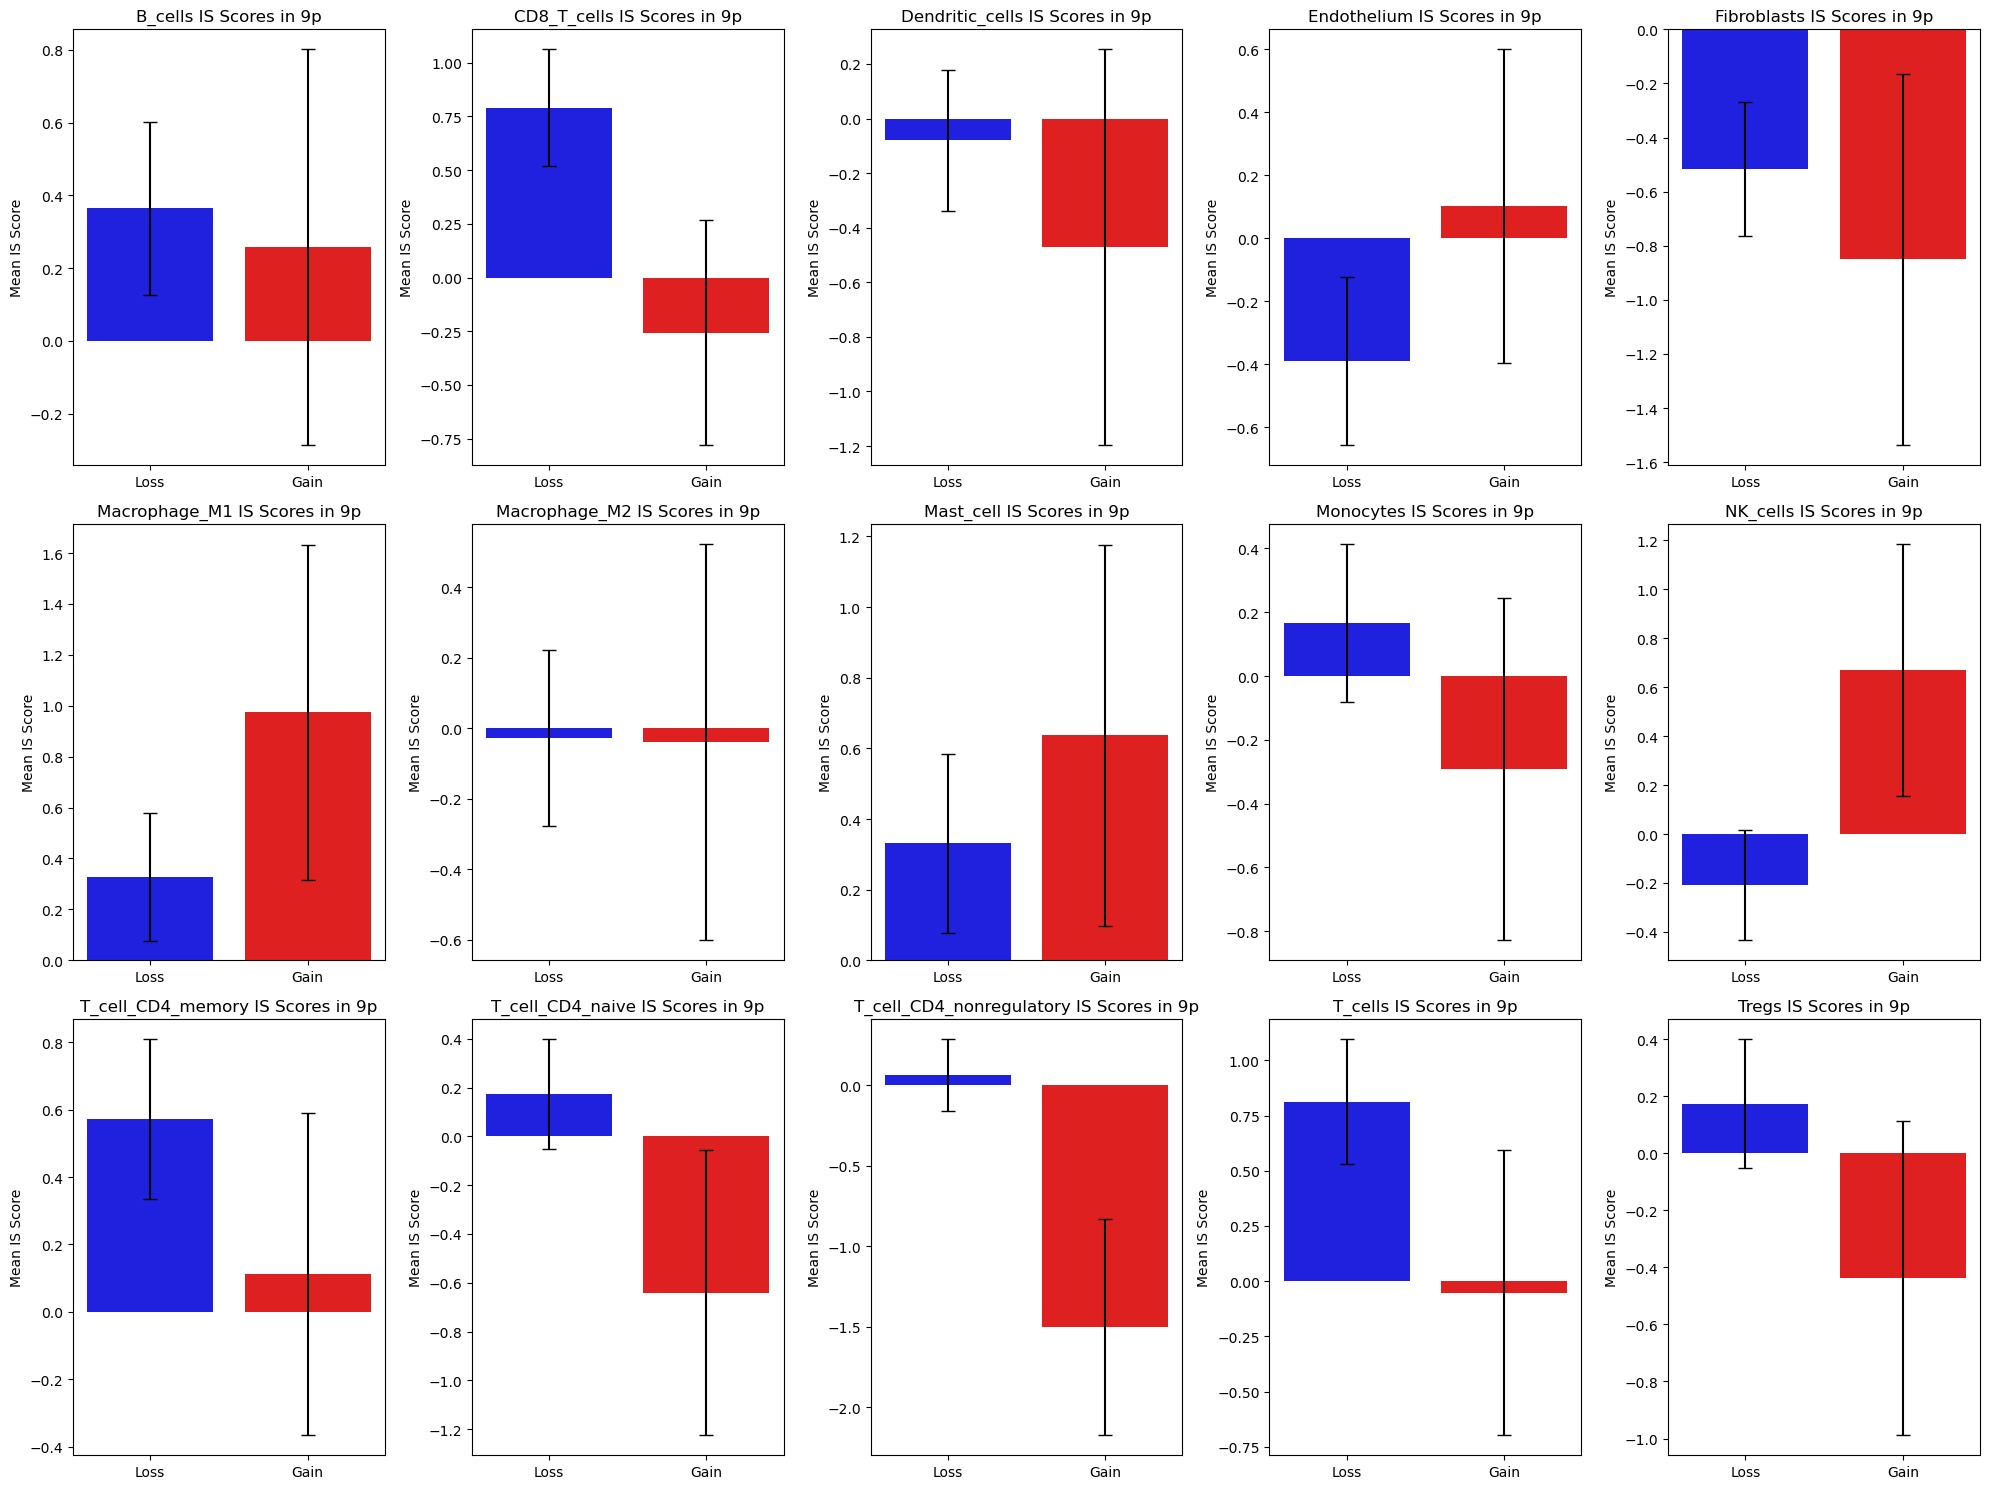

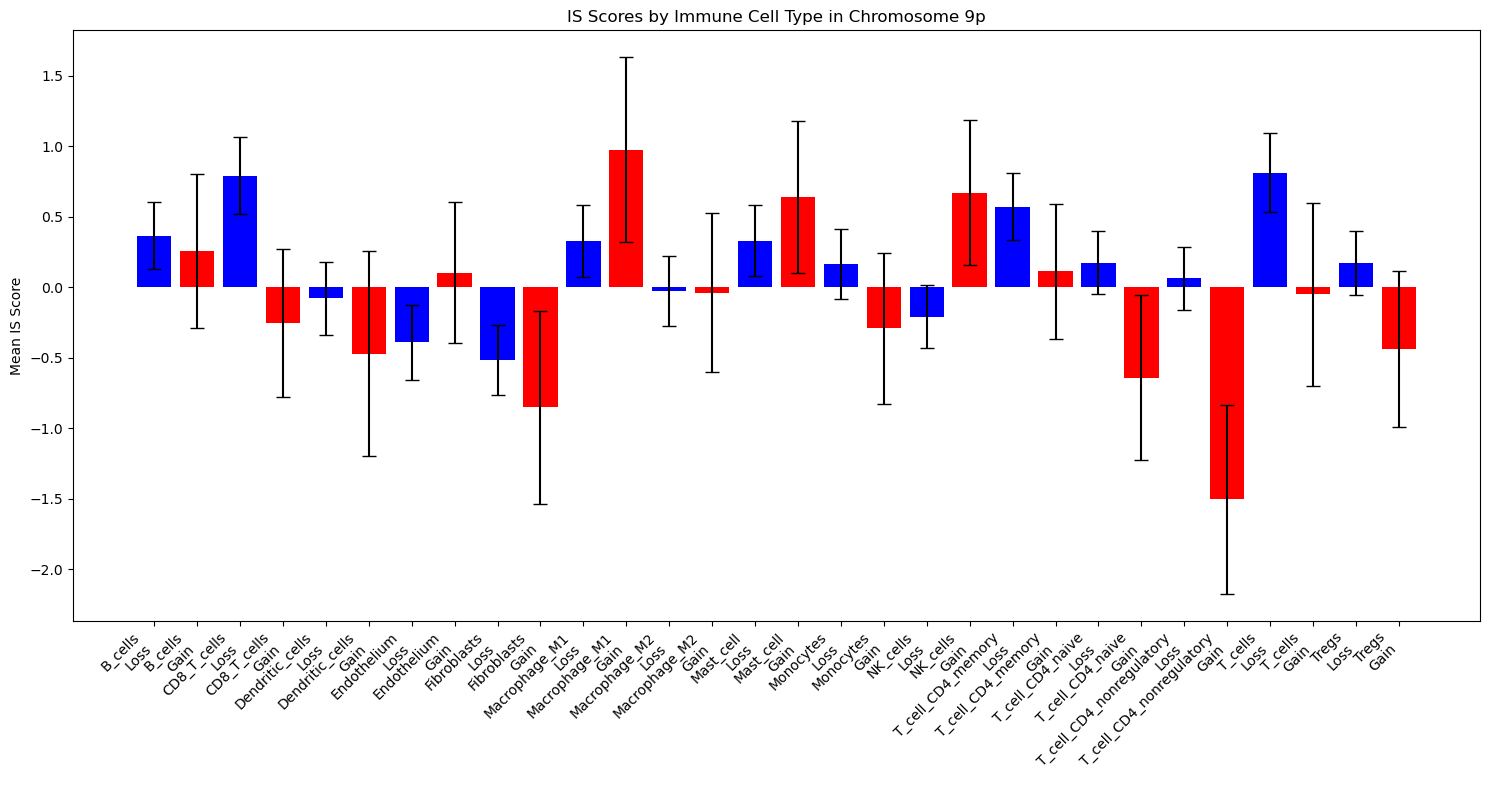

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assume df_luad is already loaded, filtered, and cleaned.
# Example:
# df_luad = pd.read_csv("your_csv_file.csv", sep=",", encoding="utf-8-sig")
# df_luad.columns = df_luad.columns.str.strip()

# Define the cell types to exclude.
exclude_cells = {"CD4_T_cells", "Eosinophil", "Lymphocytes", "Macrophages", "Neutrophils"}

# Build the list of immune cell types from columns ending with ".Coefficients",
# excluding "TumorType" and the ones in our exclusion list.
immune_cells = sorted(set([col.split('.')[0] for col in df_luad.columns 
                             if col.endswith("Coefficients") 
                             and col.split('.')[0] != "TumorType"
                             and col.split('.')[0] not in exclude_cells]))
print("Immune cell types to plot:", immune_cells)

# Create subplots for each immune cell type using 5 columns and 3 rows.
ncols = 5
nrows = 3
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 15))
axes = axes.ravel()

# Plot for each immune cell type for chromosome arm 9p.
for idx, cell_type in enumerate(immune_cells):
    # Build the column names.
    chrarm_col = f"{cell_type}.ChrArm"
    event_col  = f"{cell_type}.Event"
    coef_col   = f"{cell_type}.Coefficients"
    se_col     = f"{cell_type}.Std_Error"
    
    # Check that required columns exist.
    if not all(col in df_luad.columns for col in [chrarm_col, event_col, coef_col, se_col]):
        continue  # Skip if any column is missing
    
    # Filter rows for 9p events.
    is_9p = df_luad[chrarm_col] == 'Chr9p'
    
    # Get coefficients and events for 9p.
    is_scores = df_luad.loc[is_9p, coef_col].values
    events = df_luad.loc[is_9p, event_col].values
    # Use the provided standard error column.
    se_values = df_luad.loc[is_9p, se_col].values
    
    if len(is_scores) > 0:
        # Compute mean coefficients for Loss and Gain.
        loss_mean = np.mean(is_scores[events == 'Loss']) if np.any(events == 'Loss') else np.nan
        gain_mean = np.mean(is_scores[events == 'Gain']) if np.any(events == 'Gain') else np.nan
        
        # Compute mean standard error for Loss and Gain using the Std_Error column.
        loss_se = np.mean(df_luad.loc[is_9p & (df_luad[event_col] == 'Loss'), se_col]) if np.any(events == 'Loss') else np.nan
        gain_se = np.mean(df_luad.loc[is_9p & (df_luad[event_col] == 'Gain'), se_col]) if np.any(events == 'Gain') else np.nan
        
        # Create the bar plot for Loss and Gain.
        ax = axes[idx]
        sns.barplot(x=['Loss', 'Gain'], 
                    y=[loss_mean, gain_mean],
                    ax=ax,
                    palette=["blue", "red"])
        ax.set_title(f'{cell_type} IS Scores in 9p')
        ax.set_ylabel('Mean IS Score')
        ax.set_xlabel('')
        
        # Add error bars for Loss and Gain.
        ax.errorbar(x=[0, 1], 
                    y=[loss_mean, gain_mean],
                    yerr=[loss_se, gain_se],
                    fmt='none', color='black', capsize=5)
    else:
        # Remove the subplot if no data exists for this cell type.
        fig.delaxes(axes[idx])

# Remove any extra empty subplots.
for idx in range(len(immune_cells), len(axes)):
    fig.delaxes(axes[idx])
    
plt.tight_layout()
plt.show()


# Create a summary plot aggregating all immune cell types for 9p (only Loss and Gain)
plt.figure(figsize=(15, 8))
all_means = []
all_stds = []
labels = []

for cell_type in immune_cells:
    chrarm_col = f"{cell_type}.ChrArm"
    event_col  = f"{cell_type}.Event"
    coef_col   = f"{cell_type}.Coefficients"
    se_col     = f"{cell_type}.Std_Error"
    
    if not all(col in df_luad.columns for col in [chrarm_col, event_col, coef_col, se_col]):
        continue
    
    is_9p = df_luad[chrarm_col] == 'Chr9p'
    is_scores = df_luad.loc[is_9p, coef_col].values
    events = df_luad.loc[is_9p, event_col].values
    
    if len(is_scores) > 0:
        loss_mean = np.mean(is_scores[events == 'Loss']) if np.any(events == 'Loss') else np.nan
        gain_mean = np.mean(is_scores[events == 'Gain']) if np.any(events == 'Gain') else np.nan
        
        loss_se = np.mean(df_luad.loc[is_9p & (df_luad[event_col] == 'Loss'), se_col]) if np.any(events == 'Loss') else np.nan
        gain_se = np.mean(df_luad.loc[is_9p & (df_luad[event_col] == 'Gain'), se_col]) if np.any(events == 'Gain') else np.nan
        
        all_means.extend([loss_mean, gain_mean])
        all_stds.extend([loss_se, gain_se])
        labels.extend([f'{cell_type}\nLoss', f'{cell_type}\nGain'])

x = np.arange(len(labels))
plt.bar(x, all_means, yerr=all_stds, capsize=5, color=["blue", "red"] * (len(labels)//2))
plt.xticks(x, labels, rotation=45, ha='right')
plt.ylabel('Mean IS Score')
plt.title('IS Scores by Immune Cell Type in Chromosome 9p')
plt.tight_layout()
plt.savefig('IS_scores_immune_cells_9p_summary.png', dpi=300, bbox_inches='tight')
plt.show()


In [17]:
# Confirm data types
print(cnv_9p.dtypes)

Arm9p                     float64
Arm19p                    float64
19p12                     float64
19p13.11                  float64
19p13.12                  float64
19p13.13                  float64
19p13.2                   float64
19p13.3                   float64
9p11.2                    float64
9p12                      float64
9p13.1                    float64
9p13.2                    float64
9p13.3                    float64
9p21.1                    float64
9p21.2                    float64
9p21.3                    float64
9p22.1                    float64
9p22.2                    float64
9p22.3                    float64
9p23                      float64
9p24.1                    float64
9p24.2                    float64
9p24.3                    float64
Auto_CNV_Category_9p       object
Manual_CNV_Category_9p     object
dtype: object


/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_15851/476769468.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cytoband_9p_means, x="Cytoband", y="Mean_CNV", palette="coolwarm")


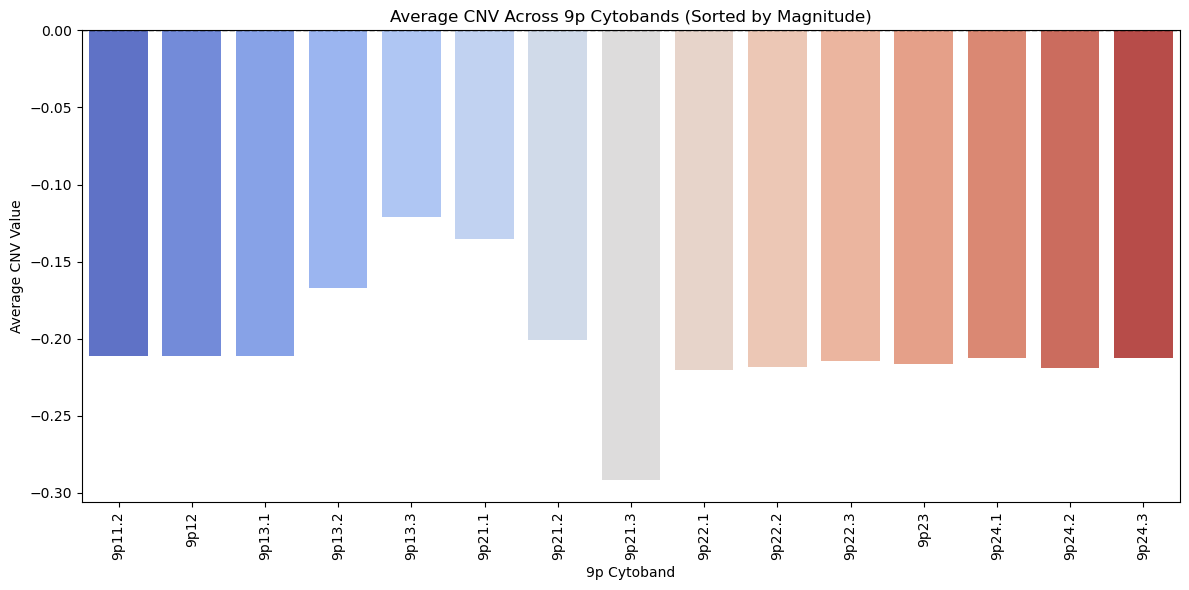

In [18]:
# Filter only columns that start with "9p" AND are numeric
cytoband_9p_cols = [col for col in cnv_data.columns if col.startswith("9p") and cnv_data[col].dtype != "object"]

# Subset CNV data to just those
cnv_9p = cnv_data[cytoband_9p_cols]

# Mean CNV value per cytoband across all patients
cytoband_9p_means = cnv_9p.mean(axis=0).reset_index()
cytoband_9p_means.columns = ["Cytoband", "Mean_CNV"]

# Plot 
plt.figure(figsize=(12, 6))
sns.barplot(data=cytoband_9p_means, x="Cytoband", y="Mean_CNV", palette="coolwarm")

plt.xticks(rotation=90)
plt.ylabel("Average CNV Value")
plt.xlabel("9p Cytoband")
plt.title("Average CNV Across 9p Cytobands (Sorted by Magnitude)")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

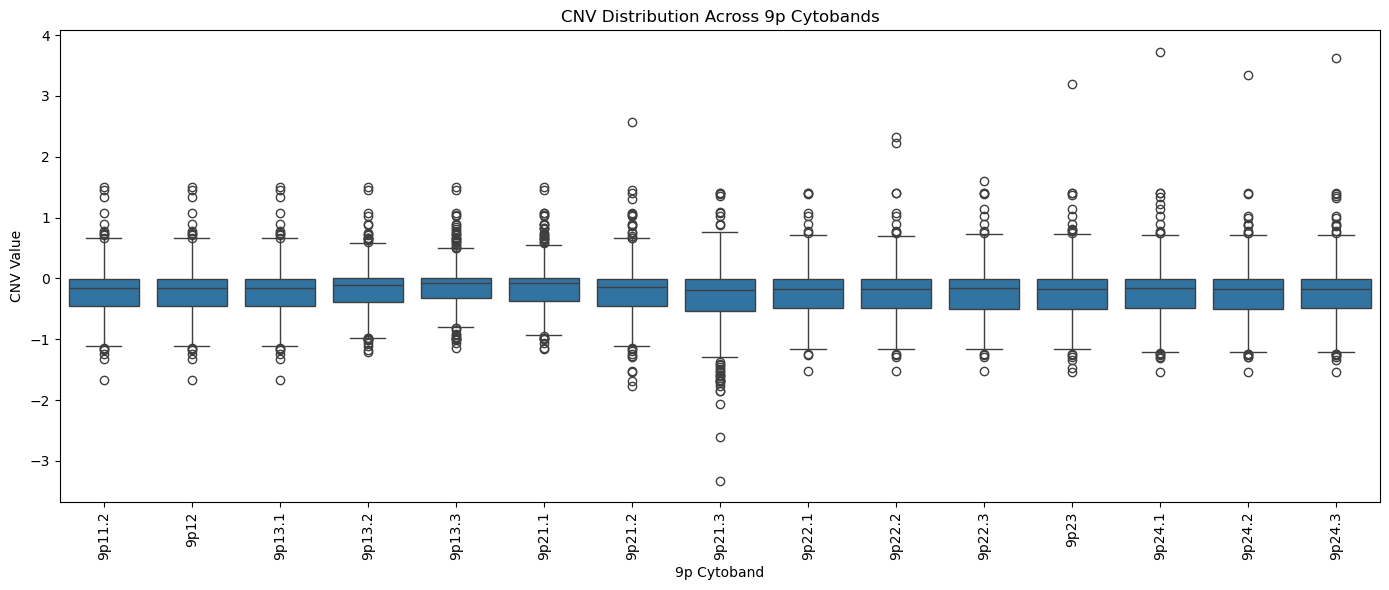

In [19]:
# Convert CNV to long format for 9p
cnv_9p_long = cnv_9p.stack().reset_index()
cnv_9p_long.columns = ["Patient", "Cytoband", "CNV"]

# Sort cytobands by 9p order
cnv_9p_long["Cytoband"] = pd.Categorical(cnv_9p_long["Cytoband"], categories=cytoband_9p_cols, ordered=True)

# Plot boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(data=cnv_9p_long, x="Cytoband", y="CNV")
plt.xticks(rotation=90)
plt.xlabel("9p Cytoband")
plt.ylabel("CNV Value")
plt.title("CNV Distribution Across 9p Cytobands")
plt.tight_layout()
plt.show()

In [21]:
# Average CNV values across 9p 21 
cnv_data["CNV_9p21_combined"] = cnv_data[["9p21.1", "9p21.2", "9p21.3"]].mean(axis=1)

cnv_data["Manual_CNV_9p21"] = "Neutral"
cnv_data.loc[cnv_data["CNV_9p21_combined"] >= manual_gain_threshold, "Manual_CNV_9p21"] = "Gain"
cnv_data.loc[cnv_data["CNV_9p21_combined"] <= manual_loss_threshold, "Manual_CNV_9p21"] = "Loss"


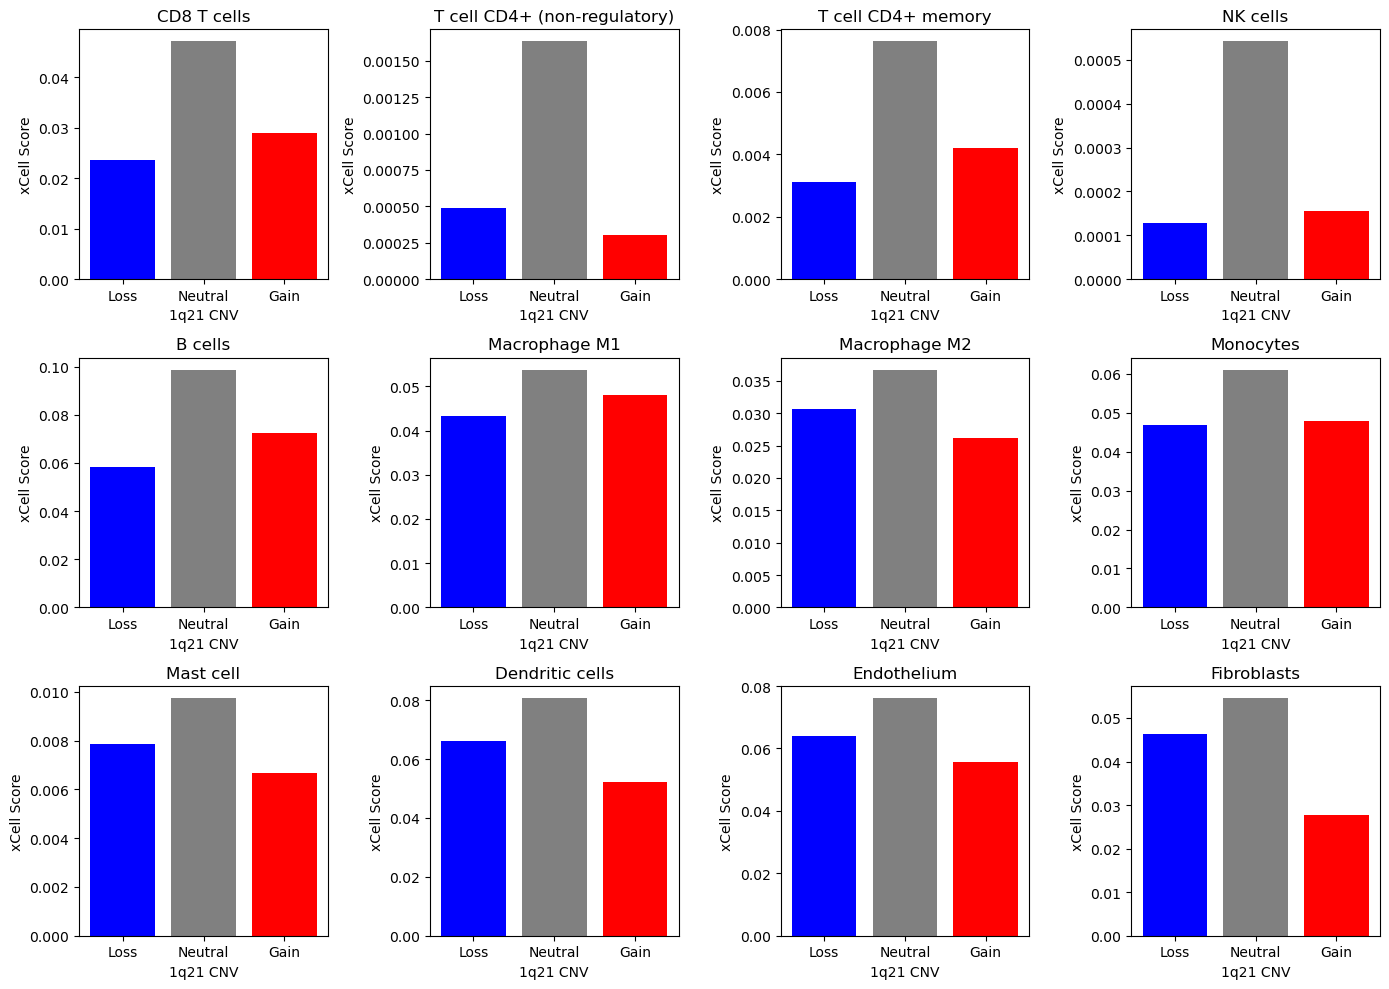

In [24]:
# Merge xCell with new CNV classification
merged_data = xcell_data.join(cnv_data["Manual_CNV_9p21"], how="inner")

# Compute mean immune scores per category
immune_means_1q21 = merged_data.groupby("Manual_CNV_9p21")[custom_order].mean()

# Define CNV colors
cnv_colors = {"Loss": "blue", "Neutral": "gray", "Gain": "red"}

# Plot
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for i, cell in enumerate(custom_order):
    bars = immune_means_1q21.loc[["Loss", "Neutral", "Gain"], cell]  # ensure consistent order
    axes[i].bar(bars.index, bars.values, color=[cnv_colors[x] for x in bars.index])
    axes[i].set_title(cell.replace("_", " "))
    axes[i].set_ylabel("xCell Score")
    axes[i].set_xlabel("1q21 CNV")

plt.tight_layout()
plt.show()

In [11]:
xcell_data_normalized = xcell_data.div(xcell_data.sum(axis=1), axis=0)
xcell_data_transposed = xcell_data_normalized.T  # rows = immune cells, cols = patients

# get matched sample ids 
sample_ids = cnv_data.index.intersection(xcell_data_transposed.columns)
cnv_1q = cnv_data.loc[sample_ids, "1q_category"]
cnv_9p = cnv_data.loc[sample_ids, "Manual_CNV_Category_9p"]

In [13]:
# Color mapping for CNV categories
cnv_palette = {"Gain": "red", "Neutral": "gray", "Loss": "blue"}

# Map to color bars
col_colors = pd.DataFrame({
    "1q CNV": cnv_1q.map(cnv_palette),
    "9p CNV": cnv_9p.map(cnv_palette)
}, index=sample_ids)

In [14]:
# Define the order you want it to appear 
custom_order = [
    "CD8_T_cells",
    "T cell CD4+ (non-regulatory)",  
    "T cell CD4+ memory",  
    "NK_cells",
    "B_cells",
    "Macrophage M1", "Macrophage M2",
    "Monocytes",
    "Mast cell",
    "Dendritic_cells",
    "Endothelium",
    "Fibroblasts"
]

# Reorder the immune cell rows (xcell_data_transposed already has cells as rows)
xcell_ordered = xcell_data_transposed.loc[custom_order, sample_ids]

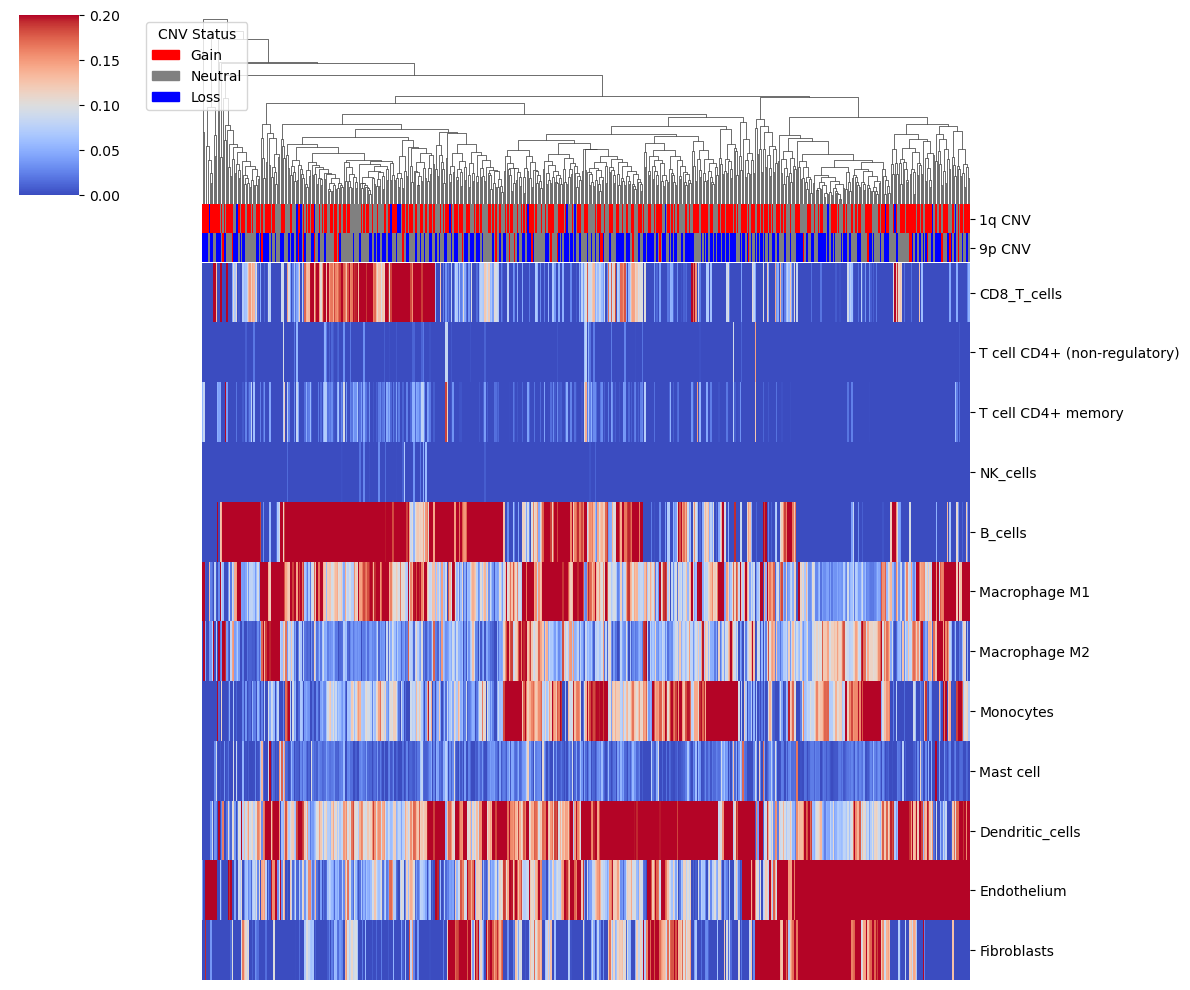

In [15]:
sns.clustermap(
    xcell_ordered,             # rows = immune cells, cols = samples
    row_cluster=False,        # Do not cluster immune cell types
    col_cluster=True,         # Cluster samples (patients) based on immune scores
    col_colors=col_colors,    # Add CNV annotations for samples
    cmap="coolwarm",
    xticklabels=False,  # Hide patient IDs on x-axis
    vmin=0, vmax=0.2,
    figsize=(12, 10)
)

import matplotlib.patches as mpatches

legend_patches = [
    mpatches.Patch(color="red", label="Gain"),
    mpatches.Patch(color="grey", label="Neutral"),
    mpatches.Patch(color="blue", label="Loss")
]

plt.legend(
    handles=legend_patches,
    title="CNV Status",
    bbox_to_anchor=(2, 1),
    loc="upper left"
)

Unique CNV Categories for 1q: Index(['Gain', 'Loss', 'Neutral'], dtype='object', name='CNV_Category_1q')
Unique CNV Categories for 9p: Index(['Gain', 'Loss', 'Neutral'], dtype='object', name='CNV_Category_9p')


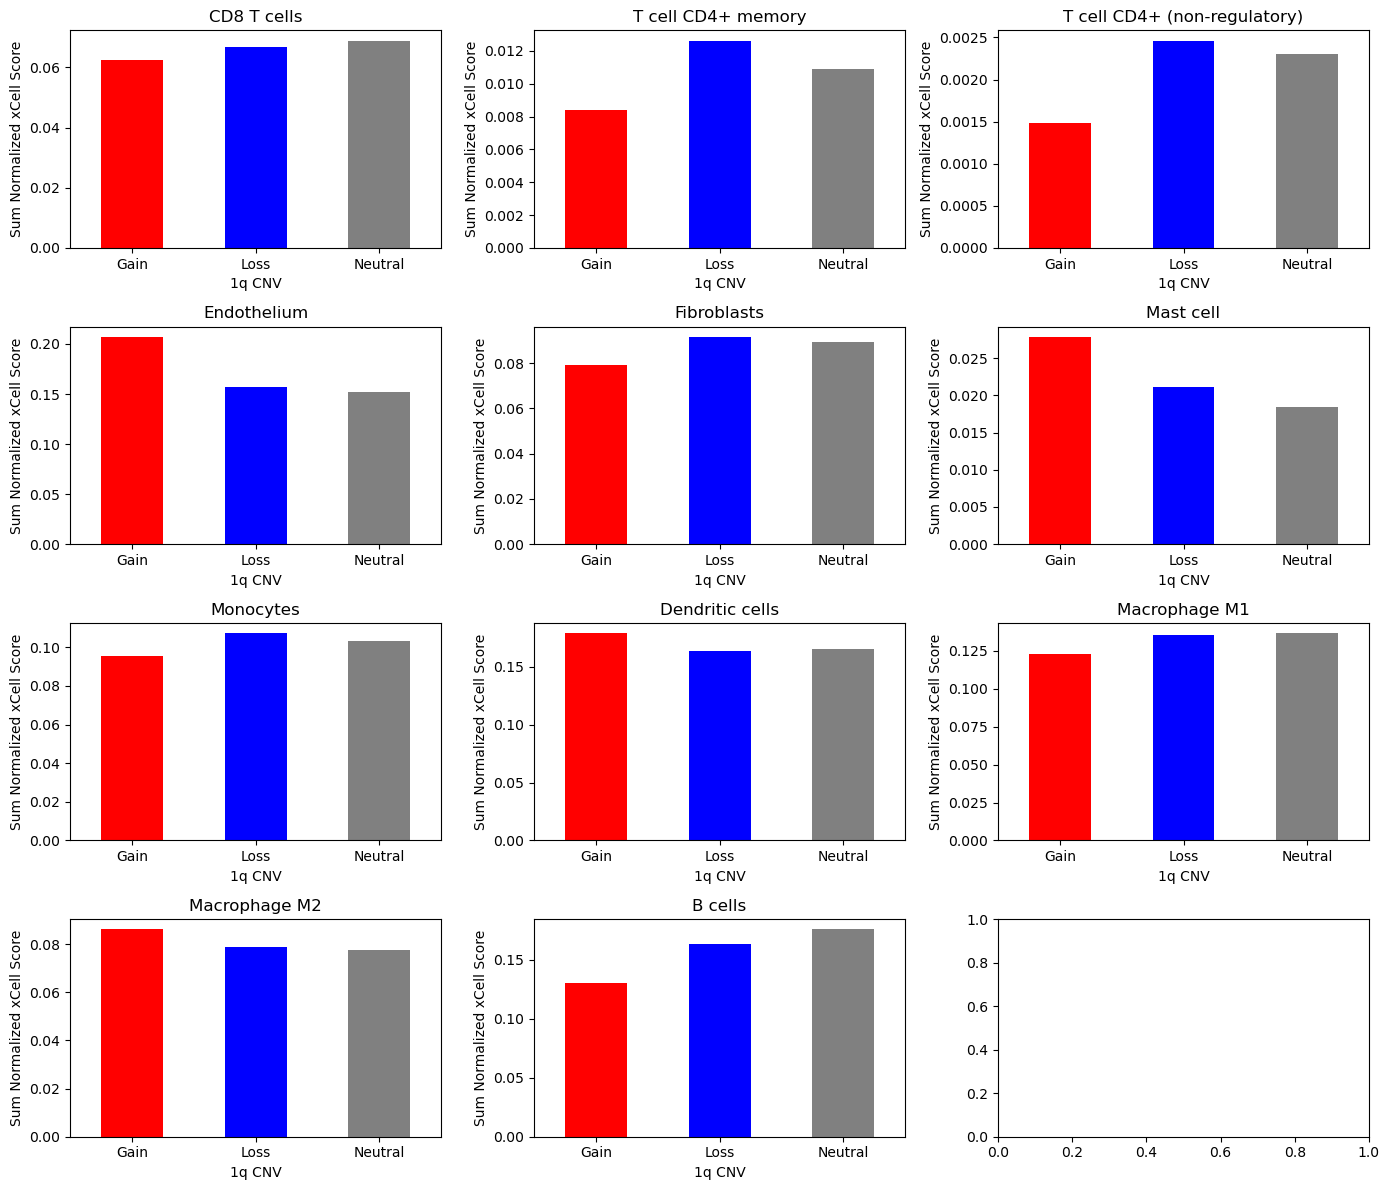

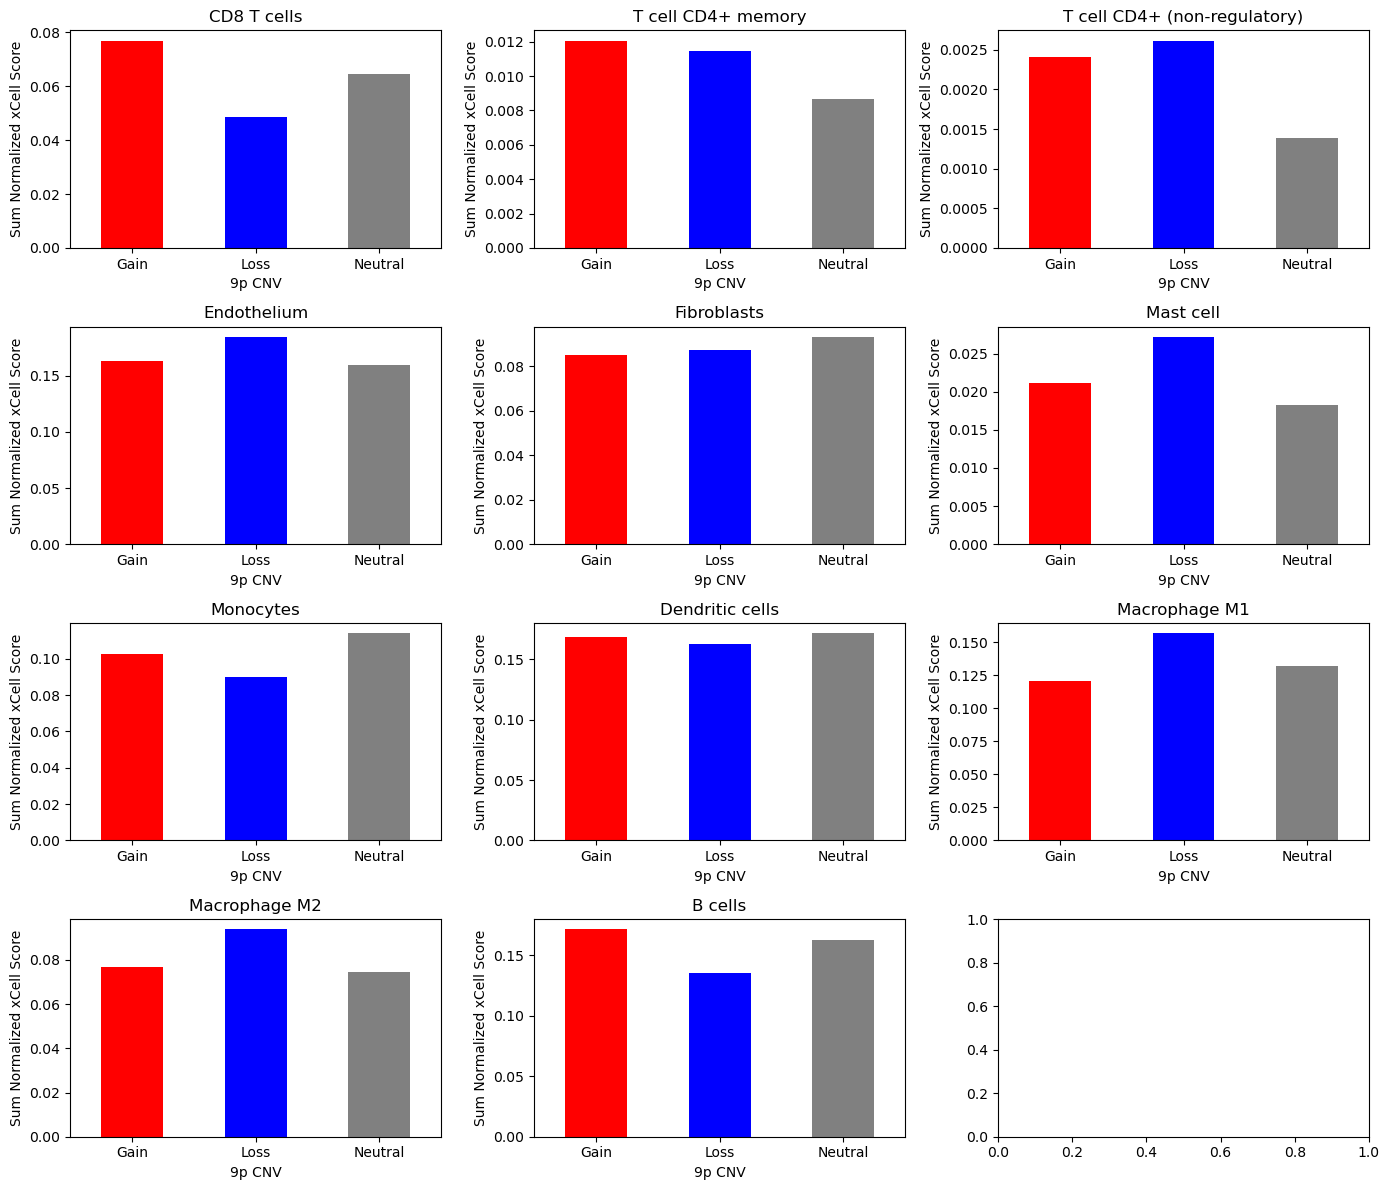

In [12]:
# Merge immune data with CNV classification
merged_data = xcell_data.join(cnv_data[["CNV_Category_1q", "CNV_Category_9p"]], how="inner")

# Compute mean immune scores per CNV category
immune_means_1q = merged_data.groupby("CNV_Category_1q")[selected_cells].mean()
immune_means_9p = merged_data.groupby("CNV_Category_9p")[selected_cells].mean()

# Debugging Step: Print Unique CNV Categories
print("Unique CNV Categories for 1q:", immune_means_1q.index.unique())
print("Unique CNV Categories for 9p:", immune_means_9p.index.unique())

# Define CNV colors
cnv_colors = {"Gain": "red", "Neutral": "gray", "Loss": "blue"}

# Plot Bar Charts for Each Cell Type (1q)
fig, axes = plt.subplots(4, 3, figsize=(14, 12))
axes = axes.flatten()

for i, cell in enumerate(selected_cells):
    immune_means_1q[cell].plot(kind="bar", color=[cnv_colors[x] for x in immune_means_1q.index], ax=axes[i])
    axes[i].set_title(cell.replace("_", " "))
    axes[i].set_xlabel("1q CNV")
    axes[i].set_ylabel("xCell Score")
    axes[i].set_xticklabels(immune_means_1q.index, rotation=0)

plt.tight_layout()
plt.show()

# Plot Bar Charts for Each Cell Type (9p)
fig, axes = plt.subplots(4, 3, figsize=(14, 12))
axes = axes.flatten()

for i, cell in enumerate(selected_cells):
    immune_means_9p[cell].plot(kind="bar", color=[cnv_colors[x] for x in immune_means_9p.index], ax=axes[i])
    axes[i].set_title(cell.replace("_", " "))
    axes[i].set_xlabel("9p CNV")
    axes[i].set_ylabel("xCell Score")
    axes[i].set_xticklabels(immune_means_9p.index, rotation=0)

plt.tight_layout()
plt.show()

/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_1378/1702409824.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cnv_numeric = merged_data[["CNV_Category_1q", "CNV_Category_9p"]].replace({"Gain": 1, "Neutral": 0, "Loss": -1})


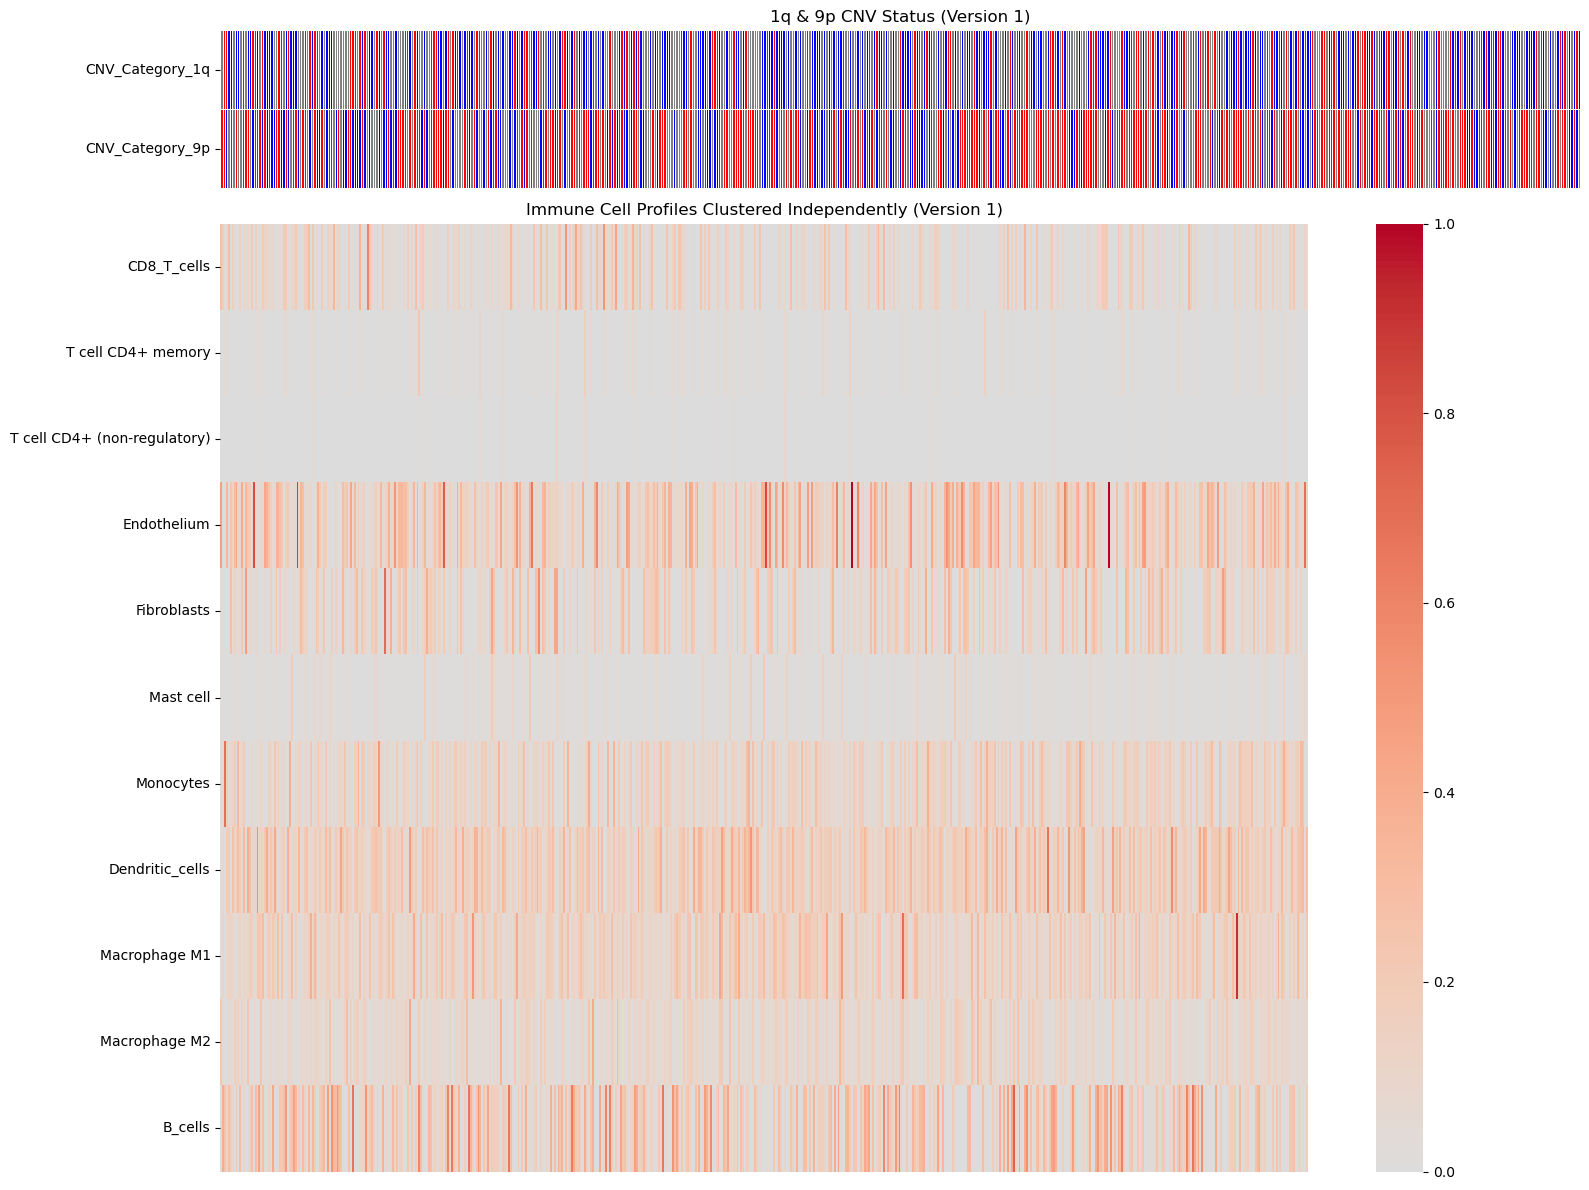

In [14]:
# Convert CNV categories to numeric values for heatmap
cnv_numeric = merged_data[["CNV_Category_1q", "CNV_Category_9p"]].replace({"Gain": 1, "Neutral": 0, "Loss": -1})

# ------------------------- Version 1: Cluster by Immune Cells Only -------------------------

fig, axes = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={"height_ratios": [1, 6]})

# Plot CNV status on top (only for 1q & 9p)
sns.heatmap(cnv_numeric.T, cmap=["blue", "gray", "red"], cbar=False, ax=axes[0], linewidths=0.5, xticklabels=False)

# Plot immune data heatmap (Clustered by immune cells)
sns.heatmap(merged_data[selected_cells].T, cmap="coolwarm", center=0, ax=axes[1], xticklabels=False)

axes[0].set_title("1q & 9p CNV Status (Version 1)")
axes[1].set_title("Immune Cell Profiles Clustered Independently (Version 1)")

plt.tight_layout()
plt.show()

/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_1378/4170834520.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cnv_sorted_numeric = cnv_sorted[["CNV_Category_1q", "CNV_Category_9p"]].replace({"Gain": 1, "Neutral": 0, "Loss": -1})


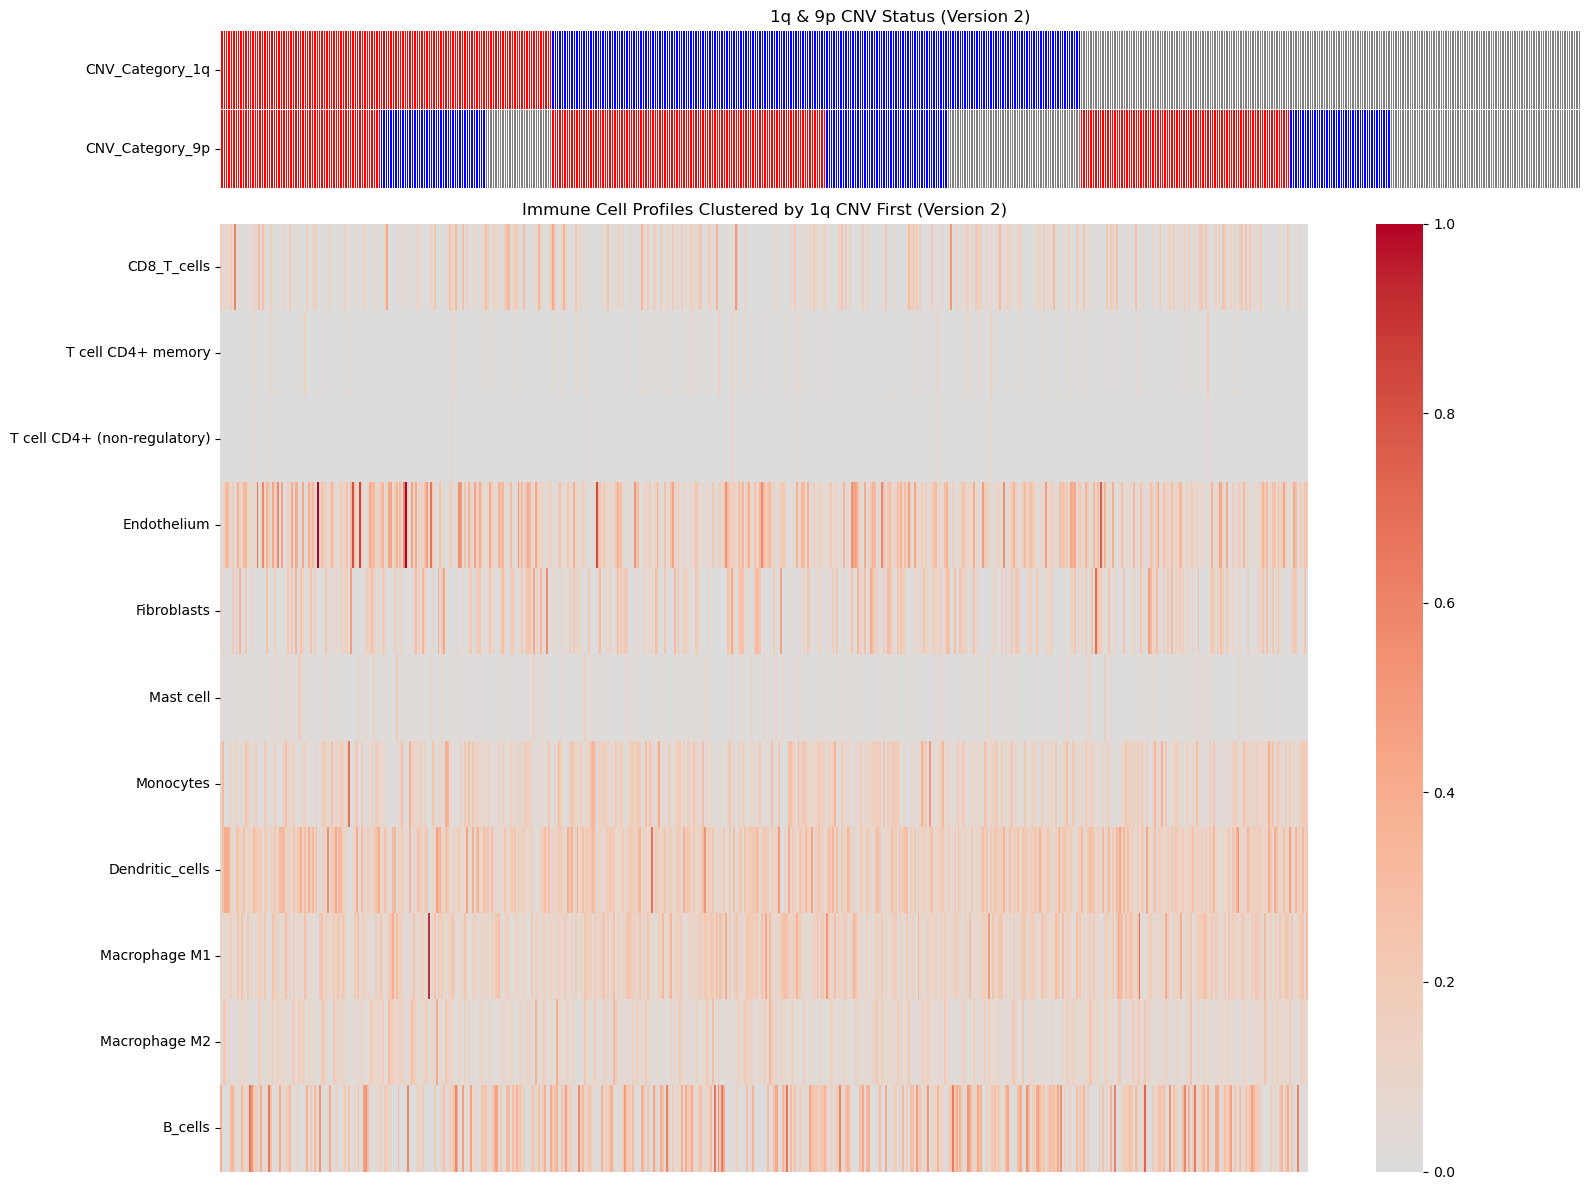

In [16]:
# ------------------------- Version 2: Cluster by CNV First, Then Immune Cells -------------------------

fig, axes = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={"height_ratios": [1, 6]})

# Sort data first by CNV status
cnv_sorted = merged_data.sort_values(by=["CNV_Category_1q", "CNV_Category_9p"])

# Convert CNV categories to numerical values again
cnv_sorted_numeric = cnv_sorted[["CNV_Category_1q", "CNV_Category_9p"]].replace({"Gain": 1, "Neutral": 0, "Loss": -1})

# Plot CNV status on top
sns.heatmap(cnv_sorted_numeric.T, cmap=["blue", "gray", "red"], cbar=False, ax=axes[0], linewidths=0.5, xticklabels=False)

# Plot immune data heatmap (Clustered by CNV first)
sns.heatmap(cnv_sorted[selected_cells].T, cmap="coolwarm", center=0, ax=axes[1], xticklabels=False)

axes[0].set_title("1q & 9p CNV Status (Version 2)")
axes[1].set_title("Immune Cell Profiles Clustered by 1q CNV First (Version 2)")

plt.tight_layout()
plt.show()